# Library Packages

In [361]:
#===== Set Up Library =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
# import pycountry
pd.set_option('display.max_columns', None)  # Show all columns

#---- Regression -----
from sklearn.linear_model import LinearRegression # baseline model
from sklearn.ensemble import RandomForestRegressor #perwakilan bagging
from sklearn.tree import DecisionTreeRegressor #baseline untuk ensemble model
from xgboost import XGBRegressor #perwakilan dari gradient boosted #buatan rusia
from lightgbm import LGBMRegressor #perwakilan dari gradien boosted #buatan microsoft
import sklearn.metrics as metrics

#---- Classification -----

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression


#-----------------------

from sklearn.metrics import (r2_score,mean_absolute_error,mean_squared_error)
from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_transformer, ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score

# import dalex to explain complex model
import dalex as dx

# load scikit-plot modules
import scikitplot as skplt

# load shap package for shap explanation
import shap

# load LimeTabularExplainer for LIME method
from lime.lime_tabular import LimeTabularExplainer

# Load Data & Data Understanding

***Columns Description***

1. ApplicationDate: Loan application date
2. AnnualIncome: Yearly income
3. CreditScore: Creditworthiness score
4. EmploymentStatus: Job situation
5. EducationLevel: Highest education attained
6. Experience: Work experience
7. LoanAmount: Requested loan size
8. LoanDuration: Loan repayment period
9. MaritalStatus: Applicant's marital state
10. NumberOfDependents: Number of dependents
11. HomeOwnershipStatus: Homeownership type
12. MonthlyDebtPayments: Monthly debt obligations
13. CreditCardUtilizationRate: Credit card usage percentage
14. NumberOfOpenCreditLines: Active credit lines
15. NumberOfCreditInquiries: Credit checks count
16. DebtToIncomeRatio: Debt to income proportion (lower percentage u have is good)
17. BankruptcyHistory: Bankruptcy records
18. LoanPurpose: Reason for loan
19. PreviousLoanDefaults: Prior loan defaults
20. PaymentHistory: Past payment behavior
21. LengthOfCreditHistory: Credit history duration
22. SavingsAccountBalance: Savings account amount
23. CheckingAccountBalance: Checking account funds
24. TotalAssets: Total owned assets
25. TotalLiabilities: Total owed debts
26. MonthlyIncome: Income per month
27. UtilityBillsPaymentHistory: Utility payment record
28. JobTenure: Job duration
29. NetWorth: Total financial worth (total asets - total dept u have to pay)
30. BaseInterestRate: Starting interest rate
31. InterestRate: Applied interest rate
32. MonthlyLoanPayment: Monthly loan payment
33. TotalDebtToIncomeRatio: Total debt against income
34. LoanApproved: Loan approval status
35. RiskScore: Risk assessment score

### Goals
* Membuat model yang dapat memprediksi apakah pengajuan pinjaman dari customer/nasabah itu disetujui atau tidak (1 approved dan 0 denied). Sehingga mempercepat proses persetujuan peminjaman dan mengurangi kesalahan dalam penilaian (bias).

In [362]:
df = pd.read_csv('Loan.csv')

In [363]:
df.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,2,Own,183,0.354418,1,2,0.358336,0,Home,0,29,9,7632,1202,146111,19183,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,1,Mortgage,496,0.087827,5,3,0.330274,0,Debt Consolidation,0,21,9,4627,3460,53204,9595,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,2,Rent,902,0.137414,2,0,0.244729,0,Education,0,20,22,886,895,25176,128874,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,1,Mortgage,755,0.267587,2,1,0.436244,0,Home,0,27,10,1675,1217,104822,5370,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,1,Mortgage,274,0.320535,0,0,0.078884,0,Debt Consolidation,0,26,27,1555,4981,244305,17286,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [364]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,20000.0,39.752600,11.622713,18.000000,32.000000,40.000000,48.000000,8.000000e+01
AnnualIncome,20000.0,59161.473550,40350.845168,15000.000000,31679.000000,48566.000000,74391.000000,4.853410e+05
CreditScore,20000.0,571.612400,50.997358,343.000000,540.000000,578.000000,609.000000,7.120000e+02
Experience,20000.0,17.522750,11.316836,0.000000,9.000000,17.000000,25.000000,6.100000e+01
LoanAmount,20000.0,24882.867800,13427.421217,3674.000000,15575.000000,21914.500000,30835.000000,1.847320e+05
LoanDuration,20000.0,54.057000,24.664857,12.000000,36.000000,48.000000,72.000000,1.200000e+02
NumberOfDependents,20000.0,1.517300,1.386325,0.000000,0.000000,1.000000,2.000000,5.000000e+00
MonthlyDebtPayments,20000.0,454.292700,240.507609,50.000000,286.000000,402.000000,564.000000,2.919000e+03
CreditCardUtilizationRate,20000.0,0.286381,0.159793,0.000974,0.160794,0.266673,0.390634,9.173801e-01
NumberOfOpenCreditLines,20000.0,3.023350,1.736161,0.000000,2.000000,3.000000,4.000000,1.300000e+01


Dari statistik deskripsi ini,
- ternyata ada nasabah yang job tenurenya 0, kemungkinan ini adalah outlier.
- rata - rata credit scorenya 571 (ini termasuk buruk dalam penilaian FICO)

# Data Preprocessing

### Handling data duplikat

In [365]:
df.duplicated().sum()

0

Tidak ada data yang terduplikasi.

### Handling missing value

In [366]:
df.isnull().sum()

ApplicationDate               0
Age                           0
AnnualIncome                  0
CreditScore                   0
EmploymentStatus              0
EducationLevel                0
Experience                    0
LoanAmount                    0
LoanDuration                  0
MaritalStatus                 0
NumberOfDependents            0
HomeOwnershipStatus           0
MonthlyDebtPayments           0
CreditCardUtilizationRate     0
NumberOfOpenCreditLines       0
NumberOfCreditInquiries       0
DebtToIncomeRatio             0
BankruptcyHistory             0
LoanPurpose                   0
PreviousLoanDefaults          0
PaymentHistory                0
LengthOfCreditHistory         0
SavingsAccountBalance         0
CheckingAccountBalance        0
TotalAssets                   0
TotalLiabilities              0
MonthlyIncome                 0
UtilityBillsPaymentHistory    0
JobTenure                     0
NetWorth                      0
BaseInterestRate              0
Interest

there is no missing value in this dataset

### Data type & data manipulation

In [367]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  object 
 1   Age                         20000 non-null  int64  
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  object 
 5   EducationLevel              20000 non-null  object 
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               20000 non-null  object 
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  object 
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtilizationRate   200

In [368]:
df.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,2,Own,183,0.354418,1,2,0.358336,0,Home,0,29,9,7632,1202,146111,19183,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,1,Mortgage,496,0.087827,5,3,0.330274,0,Debt Consolidation,0,21,9,4627,3460,53204,9595,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,2,Rent,902,0.137414,2,0,0.244729,0,Education,0,20,22,886,895,25176,128874,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,1,Mortgage,755,0.267587,2,1,0.436244,0,Home,0,27,10,1675,1217,104822,5370,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,1,Mortgage,274,0.320535,0,0,0.078884,0,Debt Consolidation,0,26,27,1555,4981,244305,17286,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


terdapat kolom yang memiliki tipe data yang salah yaitu pada kolom 'ApplicationDate' yang seharusnya bertipe date.

In [369]:
df['ApplicationDate'] = pd.to_datetime(df['ApplicationDate'])

In [370]:
print(df['ApplicationDate'].dtype)

datetime64[ns]


In [371]:
# I wanna make column that contain data float to rounc value
df['TotalDebtToIncomeRatio'] = round(df['TotalDebtToIncomeRatio'],3)
df['DebtToIncomeRatio'] = round(df['DebtToIncomeRatio'],3)
df['CreditCardUtilizationRate'] = round(df['CreditCardUtilizationRate'],3)
df['BaseInterestRate'] = round(df['BaseInterestRate'],3)
df['InterestRate'] = round(df['InterestRate'],3)

In [372]:
categorical = df.select_dtypes(include='object')
for col in categorical:
    print('='*20)
    print(f'Column: {col}')
    print(df[col].unique())

Column: EmploymentStatus
['Employed' 'Self-Employed' 'Unemployed']
Column: EducationLevel
['Master' 'Associate' 'Bachelor' 'High School' 'Doctorate']
Column: MaritalStatus
['Married' 'Single' 'Divorced' 'Widowed']
Column: HomeOwnershipStatus
['Own' 'Mortgage' 'Rent' 'Other']
Column: LoanPurpose
['Home' 'Debt Consolidation' 'Education' 'Other' 'Auto']


In [373]:
# Marital status encode
df['MaritalStatus'] = df['MaritalStatus'].replace({
    'Widowed':'Single',
    'Divorced':'Single'
})

In [374]:
df['MaritalStatus'].value_counts()

MaritalStatus
Married    10041
Single      9959
Name: count, dtype: int64

In [375]:
df['JobTenure'].unique()

array([11,  3,  6,  5,  4,  2, 10, 12,  8,  1,  7,  9,  0, 13, 14, 15, 16])

In [376]:
# drop people who have job tenure 0
df = df[df['JobTenure']!=0]

In [377]:
df = df.drop('ApplicationDate', axis=1)

In [378]:
# ohe = ['EmploymentStatus',
#  'HomeOwnershipStatus',
#  'LoanPurpose']

# edu= {
#     'High School': 0,
#     'Associate': 1,
#     'Bachelor': 2,
#     'Master': 3,
#     'Doctorate': 4
# }

# marital_status_mapping = {
#     'Single': 0,
#     'Married': 1
# }

# # Apply the mapping to the 'Education' column
# df['EducationLevel'] = df['EducationLevel'].map(edu)
# df['MaritalStatus'] = df['MaritalStatus'].map(marital_status_mapping)


# df = pd.get_dummies(df, columns=['EmploymentStatus', 'HomeOwnershipStatus', 'LoanPurpose'], drop_first=True)
# df.head()

In [379]:
# edu= {
#     'High School': 0,
#     'Associate': 1,
#     'Bachelor': 2,
#     'Master': 3,
#     'Doctorate': 4
# }


# # Apply the mapping to the 'Education' column
# X_train['EducationLevel'] = X_train['EducationLevel'].map(edu)
# X_test['EducationLevel'] = X_test['EducationLevel'].map(edu)


# marital_status_mapping = {
#     'Single': 0,
#     'Married': 1
# }
# X_train['MaritalStatus'] = X_train['MaritalStatus'].map(marital_status_mapping)
# X_test['MaritalStatus'] = X_test['MaritalStatus'].map(marital_status_mapping)


In [380]:
# download data cleaned
df.to_csv('clean financial', index=False)

# Exploratory Data Analysis

In [381]:
# Feature variable
X = df.drop(columns=['LoanApproved'],axis=1)
# Target variable
y = df['LoanApproved']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [382]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(13893, 34)
(5955, 34)
(13893,)
(5955,)


Distribusi Loan Approval (target variable)

In [383]:
y_train.value_counts(normalize=True)

LoanApproved
0    0.761679
1    0.238321
Name: proportion, dtype: float64

/var/folders/lk/9kxh9jzd1y3g9klnhzw1xmsm0000gn/T/ipykernel_2680/1343186794.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




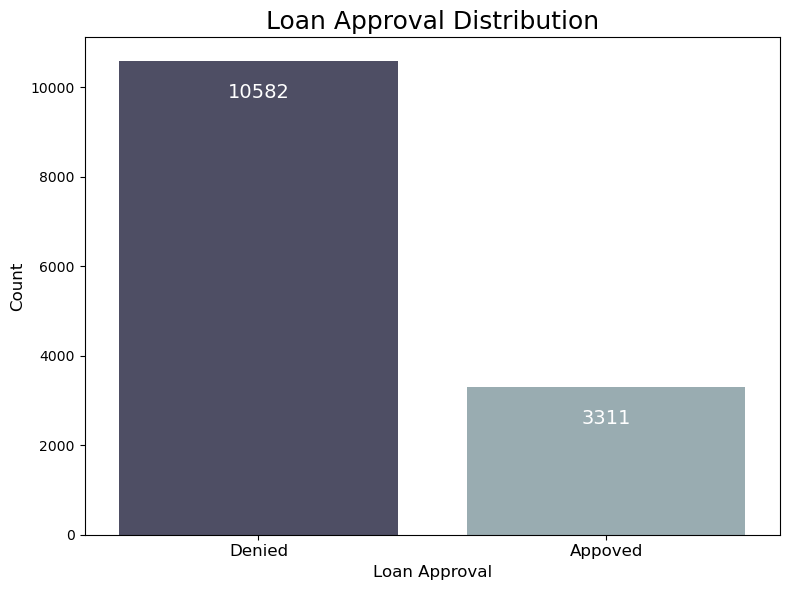

In [384]:
plt.figure(figsize=(8,6))

ax = sns.countplot(x=y_train, palette='bone')

for p in ax.patches:
    ax.annotate(f'\n{round(p.get_height())}', (p.get_x()+0.40, p.get_height()), ha='center', va='top', color='white', size=14)

plt.title('Loan Approval Distribution', size=18)
plt.xticks([0,1], ['Denied','Appoved'], size=12)
plt.xlabel('Loan Approval', size=12)
plt.ylabel('Count', size=12)
plt.tight_layout();

Ternyata pengajuan peminjaman customr lebih banyak yang di approve dari pada di tolak.

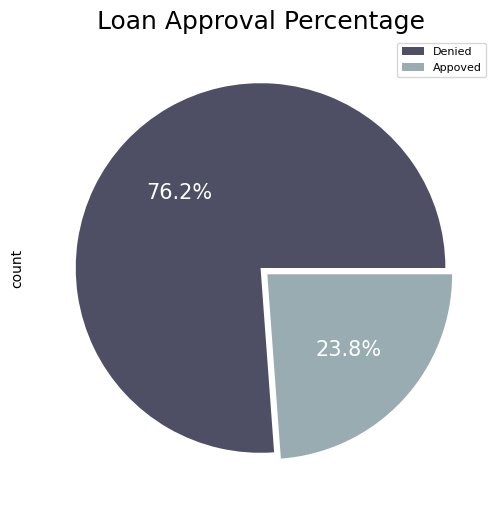

In [385]:
plt.figure(figsize=(8,6))

y_train.value_counts().plot(kind = 'pie', labels = ['',''], autopct='%1.1f%%', colors = ['#4e4e64','#99acb1'], explode = [0,0.05], textprops = {"fontsize":15, 'color':'white'})

plt.legend(labels=['Denied','Appoved'], fontsize=8)

plt.title('Loan Approval Percentage', size=18)
plt.show()

persentase antara yang diapproved(76.2%) dengan yang denied(23.8%) ini cukup signifikan perbedaannya. Saya perlu mencari tahu apa penyebab pengajuan pinjaman banyak yang tidak di Approve?

/var/folders/lk/9kxh9jzd1y3g9klnhzw1xmsm0000gn/T/ipykernel_2680/317747362.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/var/folders/lk/9kxh9jzd1y3g9klnhzw1xmsm0000gn/T/ipykernel_2680/317747362.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/var/folders/lk/9kxh9jzd1y3g9klnhzw1xmsm0000gn/T/ipykernel_2680/317747362.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/var/folders/lk/9kxh9jzd1y3g9klnhzw1xmsm0000gn/T/ipykernel_2680/317747362.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` vari

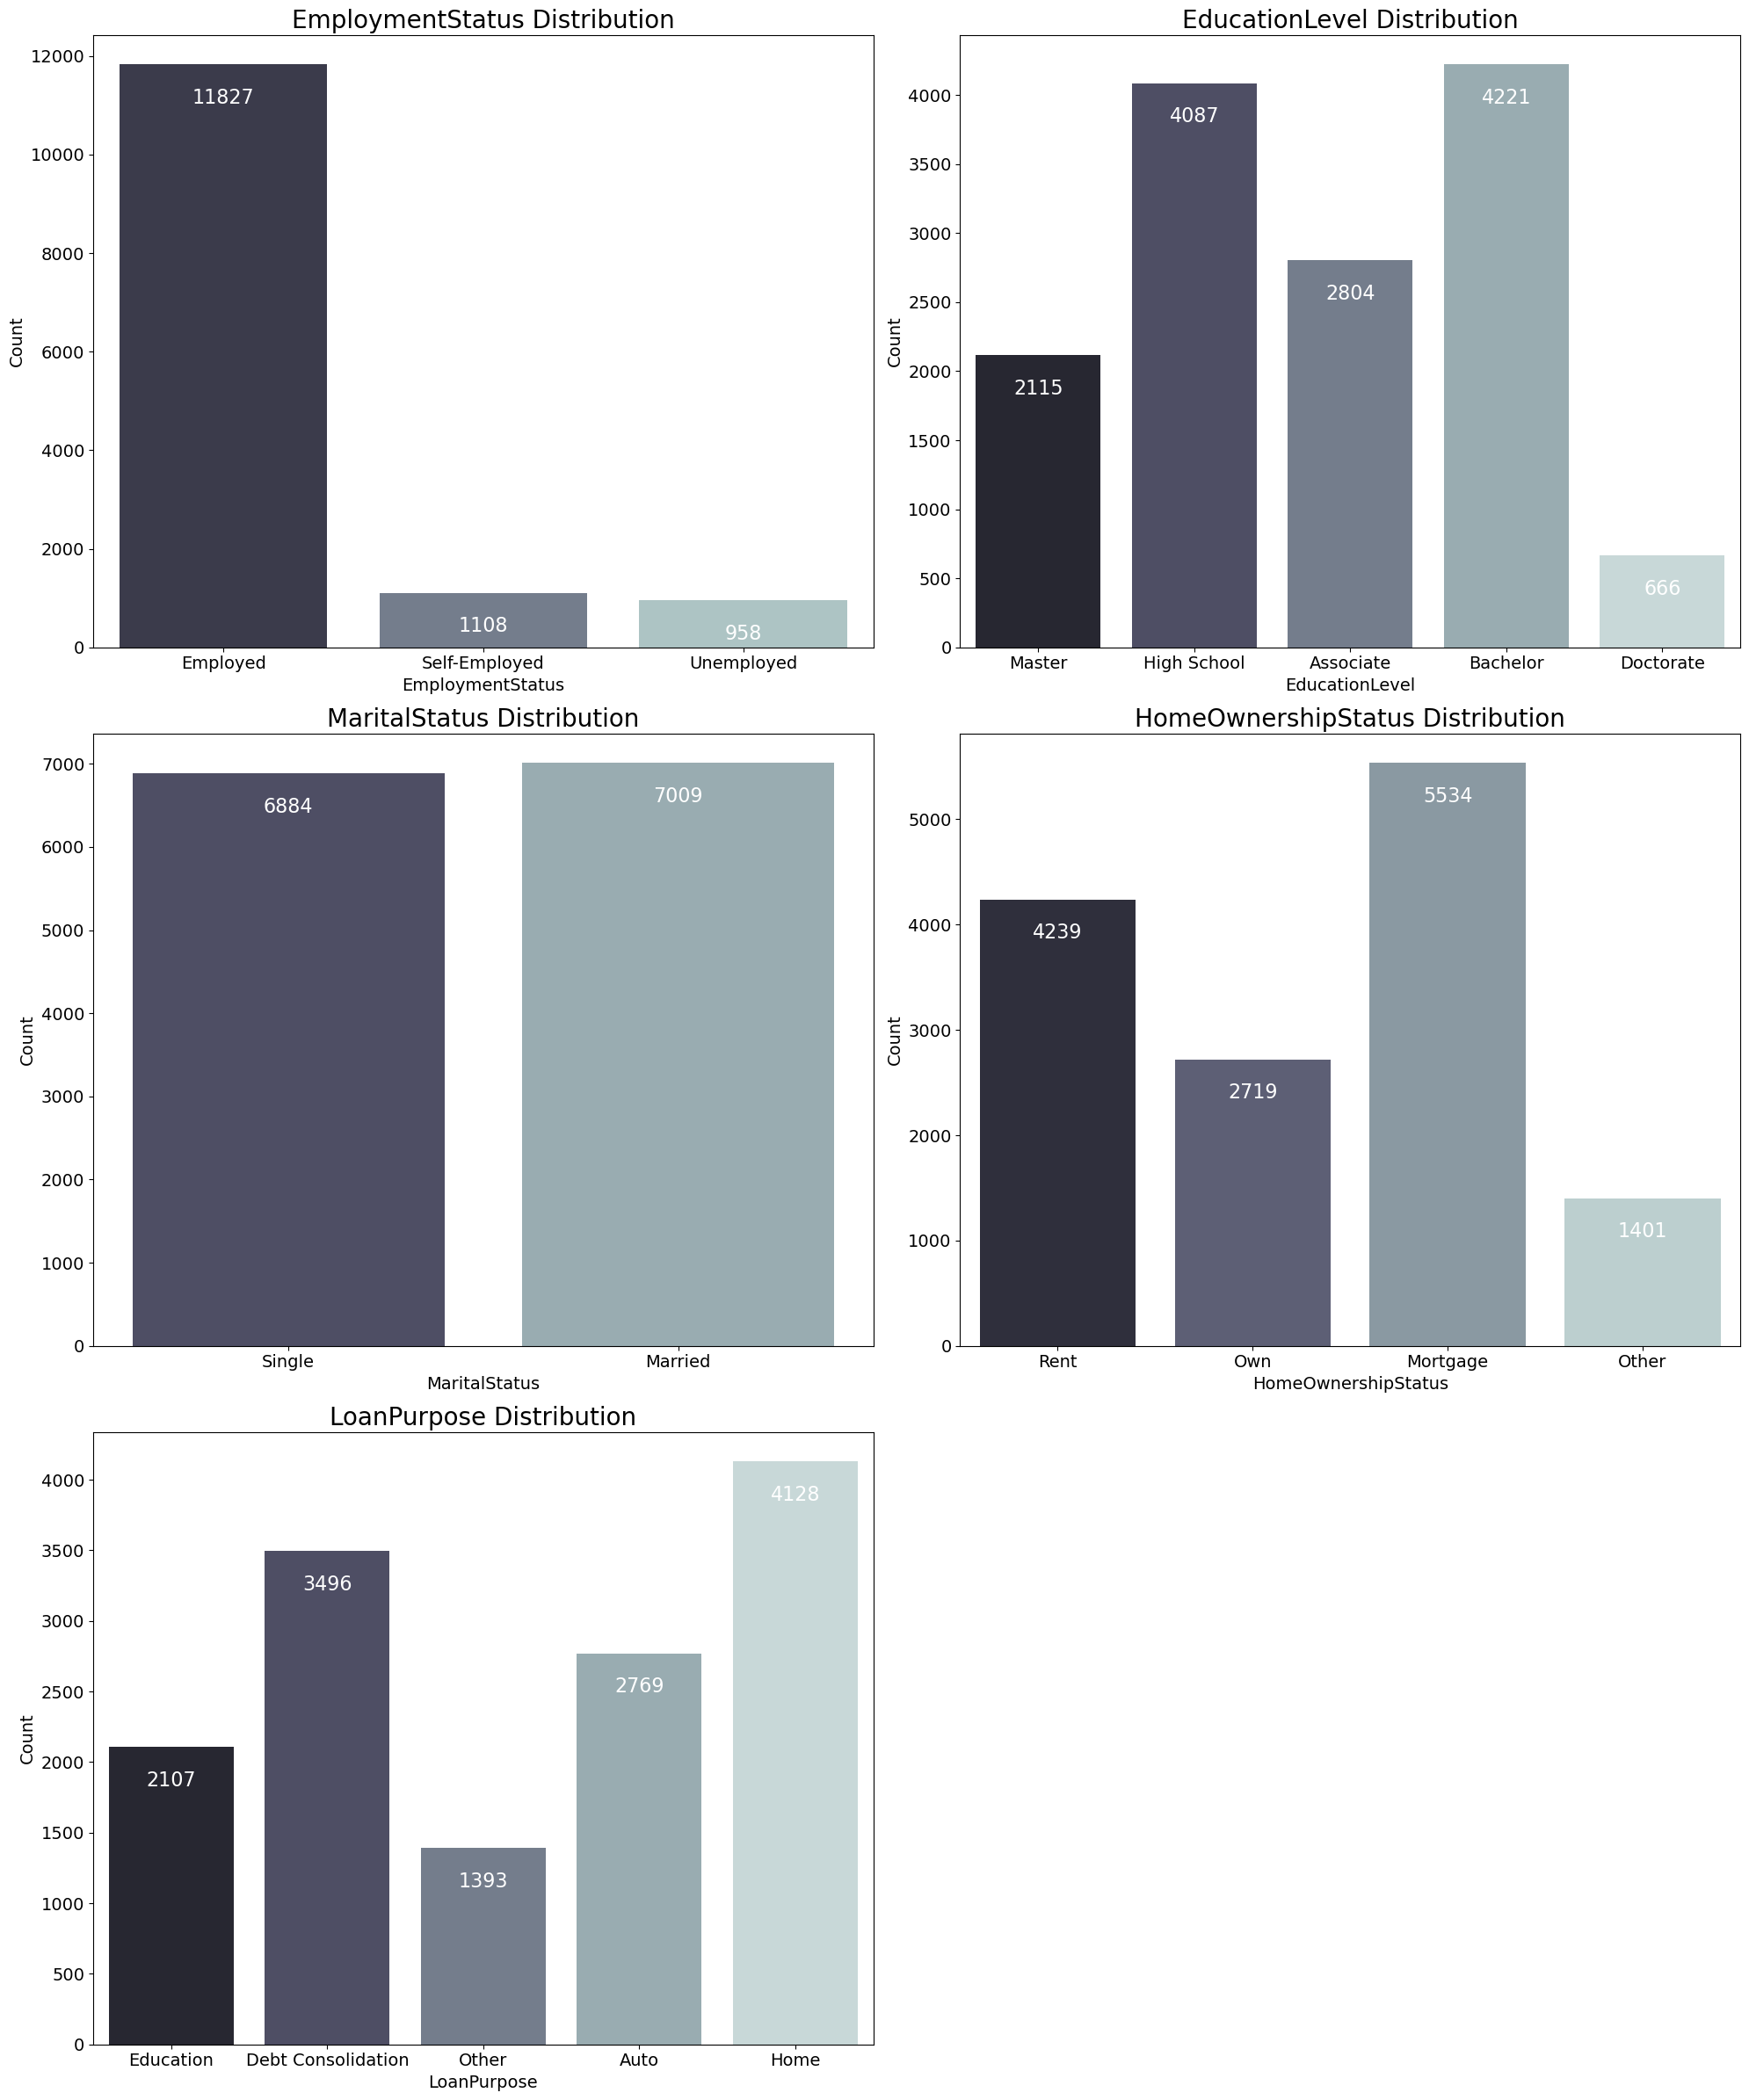

In [386]:
plt.figure(figsize=(20,24))

for i, col in enumerate(categorical):
  plt.subplot(3, 2, i+1)

  ax = sns.countplot(data=X_train, x=col,palette ='bone')
  for p in ax.patches:
      ax.annotate(f'\n{round(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='top', color='white', size=16)

  plt.title(f'{col} Distribution', size=20)
  plt.xlabel(col, size=14)
  plt.ylabel('Count', size=14)
  plt.xticks(fontsize=14)
  plt.yticks(fontsize=14)

plt.tight_layout()
plt.show()

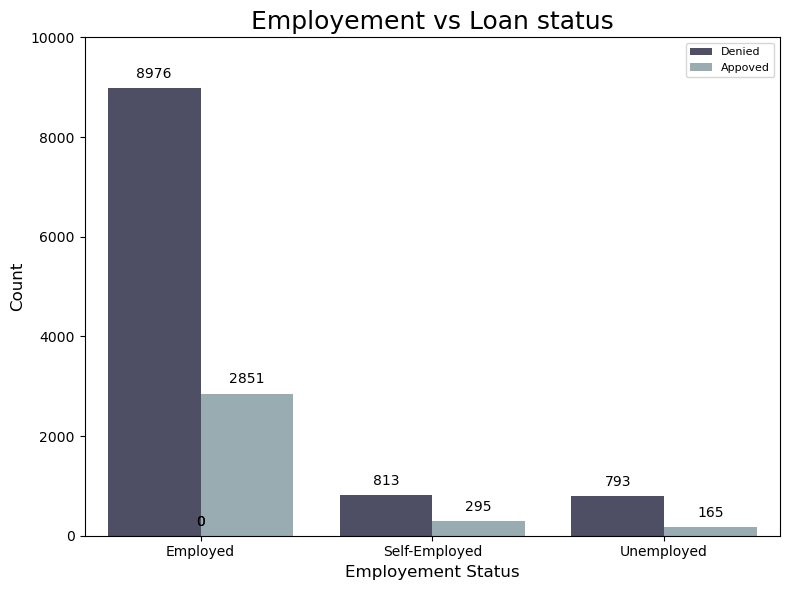

In [387]:
data = pd.DataFrame({
    'EmploymentStatus': X_train['EmploymentStatus'],
    'LoanApproved': y_train
})

plt.figure(figsize=(8,6))

ax = sns.countplot(data=data, x='EmploymentStatus', hue ='LoanApproved', palette ='bone')
for p in ax.patches:
    ax.annotate(f'\n{round(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()+750), ha='center', va='top', color='black', size=10)

plt.title('Employement vs Loan status', size=18)
plt.legend(labels=['Denied','Appoved'], fontsize=8)
plt.xlabel('Employement Status', size=12)
plt.ylabel('Count', size=12)
plt.ylim(0,10000)
plt.tight_layout()
plt.show()

Education level distribution

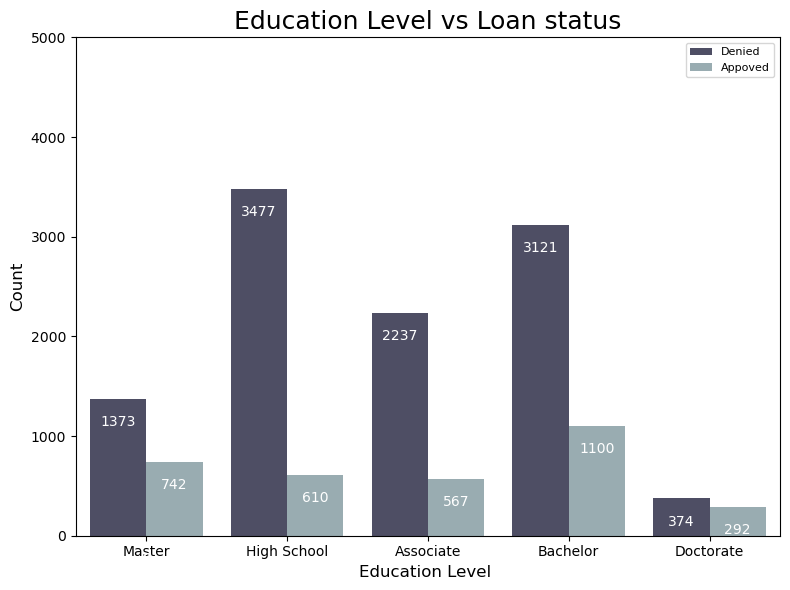

In [388]:
data = pd.DataFrame({
    'EducationLevel': X_train['EducationLevel'],
    'LoanApproved': y_train
})

plt.figure(figsize=(8,6))

ax = sns.countplot(data=data, x='EducationLevel', hue ='LoanApproved', palette ='bone')
for p in ax.patches:
    ax.annotate(f'\n{round(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='top', color='white', size=10)

plt.title('Education Level vs Loan status', size=18)
plt.legend(labels=['Denied','Appoved'], fontsize=8)
plt.xlabel('Education Level ', size=12)
plt.ylabel('Count', size=12)
plt.ylim(0,5000)
plt.tight_layout()
plt.show()

ternyata customer dengan pendidikan sarjana lebih banyak di approve pinjamannya.

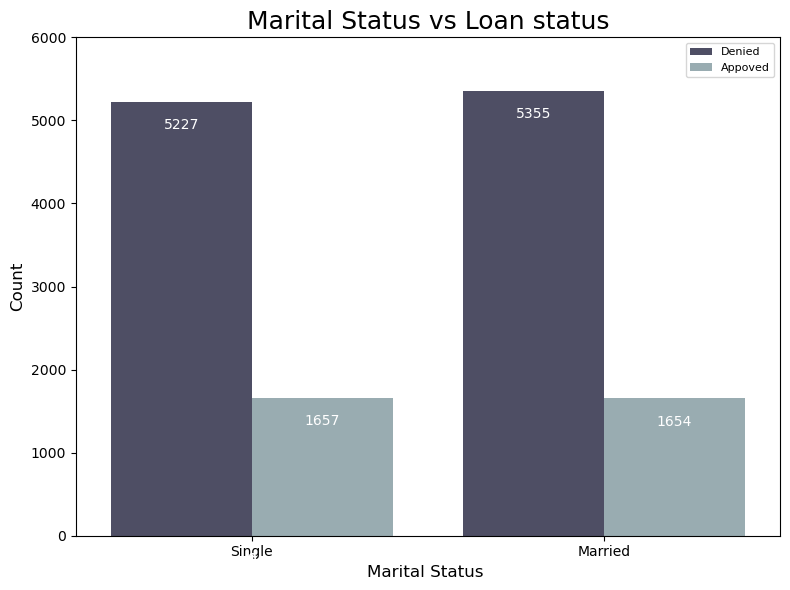

In [389]:
data = pd.DataFrame({
    'MaritalStatus': X_train['MaritalStatus'],
    'LoanApproved': y_train
})

plt.figure(figsize=(8,6))

ax = sns.countplot(data=data, x='MaritalStatus', hue ='LoanApproved', palette ='bone')
for p in ax.patches:
    ax.annotate(f'\n{round(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='top', color='white', size=10)

plt.title('Marital Status vs Loan status', size=18)
plt.legend(labels=['Denied','Appoved'], fontsize=8)
plt.xlabel('Marital Status ', size=12)
plt.ylabel('Count', size=12)
plt.ylim(0,6000)
plt.tight_layout()
plt.show()

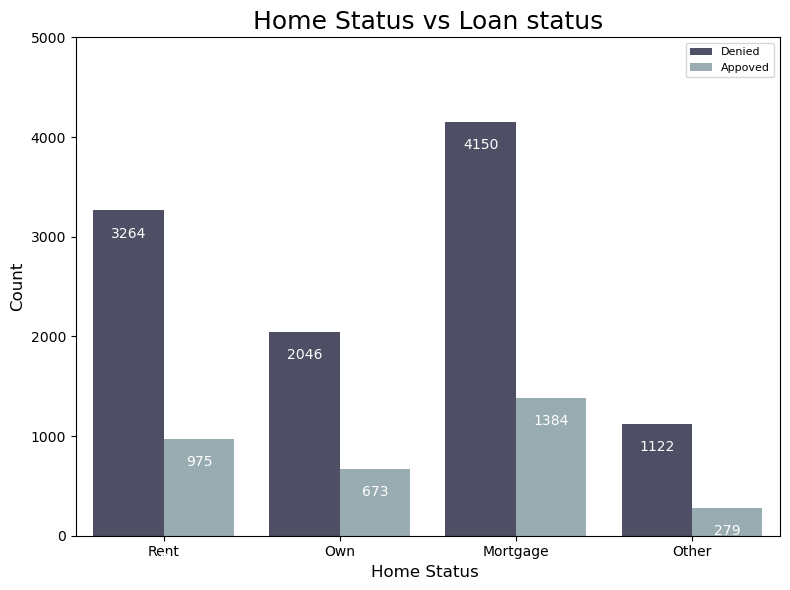

In [390]:
data = pd.DataFrame({
    'HomeOwnershipStatus': X_train['HomeOwnershipStatus'],
    'LoanApproved': y_train
})

plt.figure(figsize=(8,6))

ax = sns.countplot(data=data, x='HomeOwnershipStatus', hue ='LoanApproved', palette ='bone')
for p in ax.patches:
    ax.annotate(f'\n{round(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='top', color='white', size=10)

plt.title('Home Status vs Loan status', size=18)
plt.legend(labels=['Denied','Appoved'], fontsize=8)
plt.xlabel('Home Status ', size=12)
plt.ylabel('Count', size=12)
plt.ylim(0,5000)
plt.tight_layout()
plt.show()

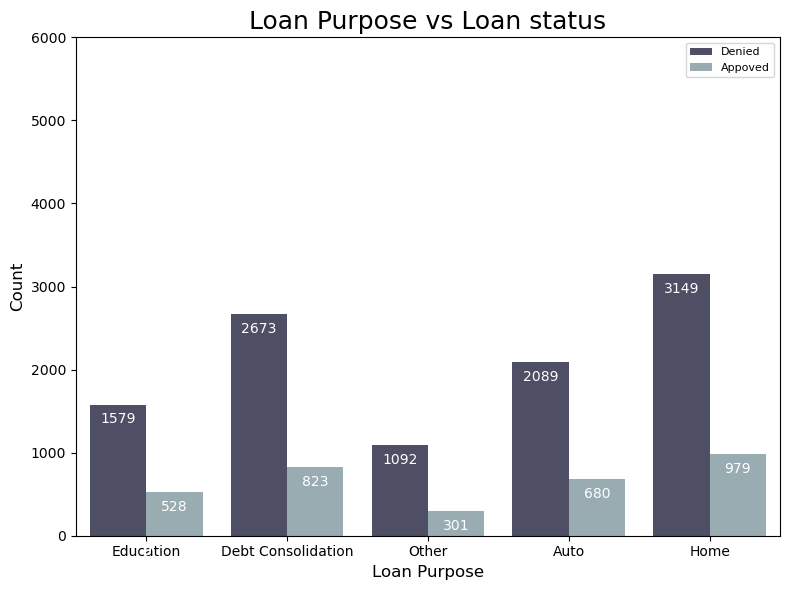

In [391]:
data = pd.DataFrame({
    'LoanPurpose': X_train['LoanPurpose'],
    'LoanApproved': y_train
})

plt.figure(figsize=(8,6))

ax = sns.countplot(data=data, x='LoanPurpose', hue ='LoanApproved', palette ='bone')
for p in ax.patches:
    ax.annotate(f'\n{round(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()+100), ha='center', va='top', color='white', size=10)

plt.title('Loan Purpose vs Loan status', size=18)
plt.legend(labels=['Denied','Appoved'], fontsize=8)
plt.xlabel('Loan Purpose', size=12)
plt.ylabel('Count', size=12)
plt.ylim(0,6000)
plt.tight_layout()
plt.show()

In [392]:
num = df.select_dtypes(include='number')
num.columns.to_list()

['Age',
 'AnnualIncome',
 'CreditScore',
 'Experience',
 'LoanAmount',
 'LoanDuration',
 'NumberOfDependents',
 'MonthlyDebtPayments',
 'CreditCardUtilizationRate',
 'NumberOfOpenCreditLines',
 'NumberOfCreditInquiries',
 'DebtToIncomeRatio',
 'BankruptcyHistory',
 'PreviousLoanDefaults',
 'PaymentHistory',
 'LengthOfCreditHistory',
 'SavingsAccountBalance',
 'CheckingAccountBalance',
 'TotalAssets',
 'TotalLiabilities',
 'MonthlyIncome',
 'UtilityBillsPaymentHistory',
 'JobTenure',
 'NetWorth',
 'BaseInterestRate',
 'InterestRate',
 'MonthlyLoanPayment',
 'TotalDebtToIncomeRatio',
 'LoanApproved',
 'RiskScore']

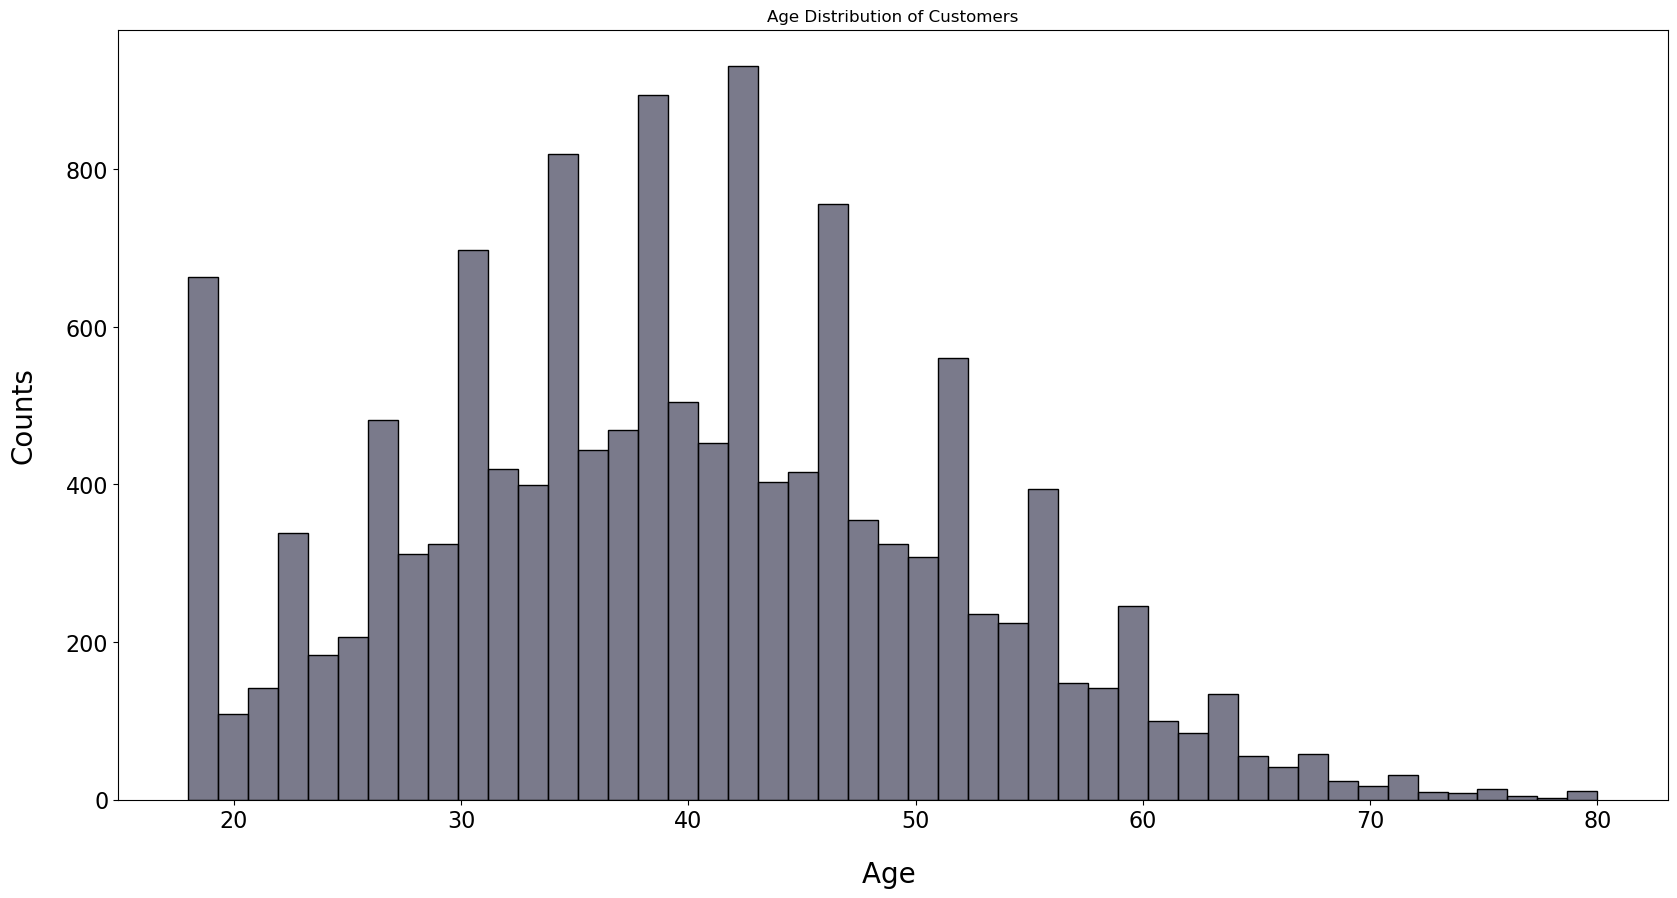

In [393]:
# Age Distribution
plt.figure(figsize=(20,10))
ax = sns.histplot(data = X_train['Age'], color='#4e4e64')
ax.set(title = "Age Distribution of Customers");
plt.xticks( fontsize=16)
plt.yticks( fontsize=16)
plt.xlabel('Age ', fontsize=20, labelpad=20)
plt.ylabel('Counts', fontsize=20, labelpad=20);

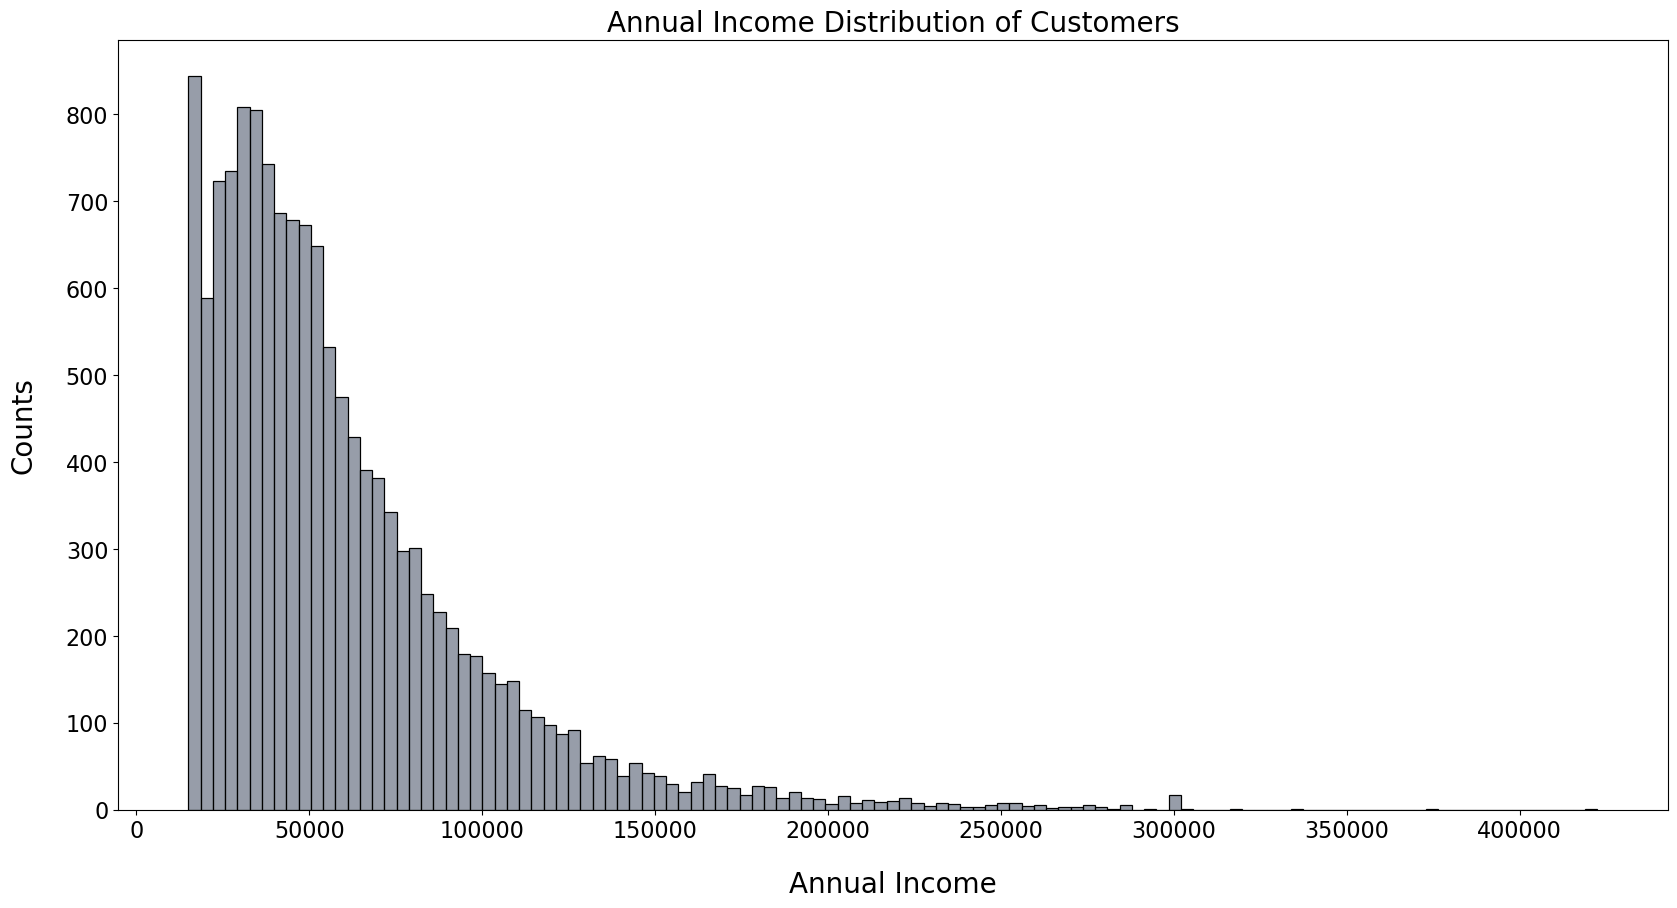

In [394]:
# Annual Income Distribution
plt.figure(figsize=(20,10))
ax = sns.histplot(data = X_train['AnnualIncome'], color='#747d8c')
plt.title("Annual Income Distribution of Customers", fontsize=20)
plt.xticks( fontsize=16)
plt.yticks( fontsize=16)
plt.xlabel('Annual Income', fontsize=20, labelpad=20)
plt.ylabel('Counts', fontsize=20, labelpad=20);

Distribusi customer berdasarkan annual income ternyata bentuknya right skew (positive skew).

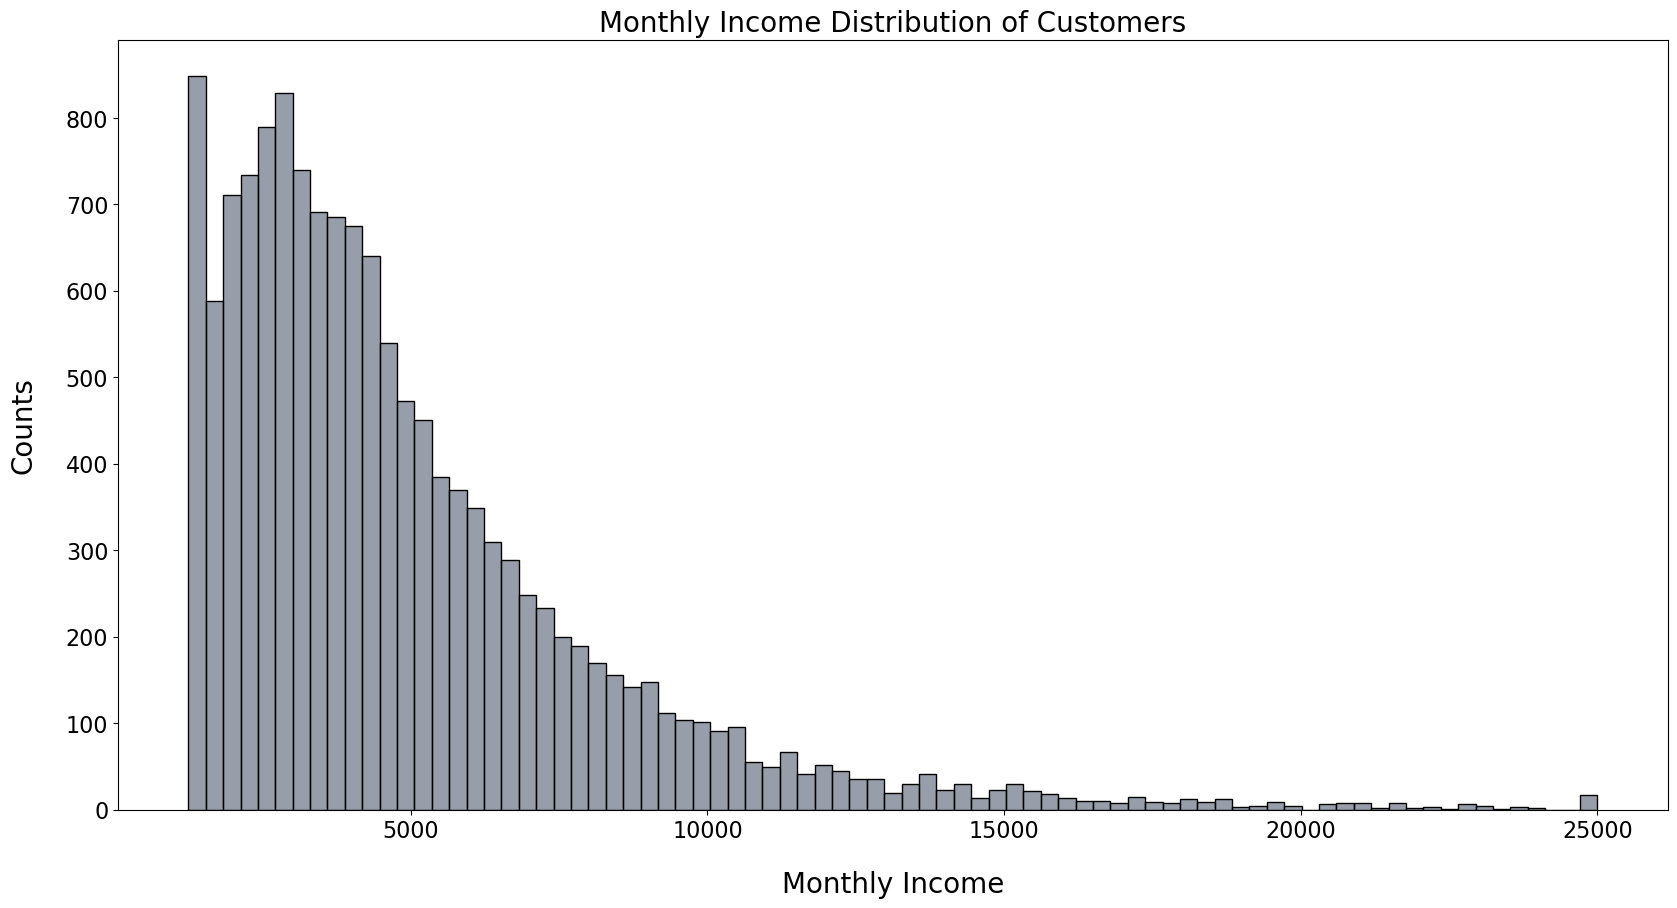

In [395]:
# Monthly Income Distribution
plt.figure(figsize=(20,10))
ax = sns.histplot(data = X_train['MonthlyIncome'], color='#747d8c')
plt.title("Monthly Income Distribution of Customers", fontsize=20)
plt.xticks( fontsize=16)
plt.yticks( fontsize=16)
plt.xlabel('Monthly Income', fontsize=20, labelpad=20)
plt.ylabel('Counts', fontsize=20, labelpad=20);

Distribusi customer berdasarkan monthly income ternyata bentuknya right skew (positive skew).

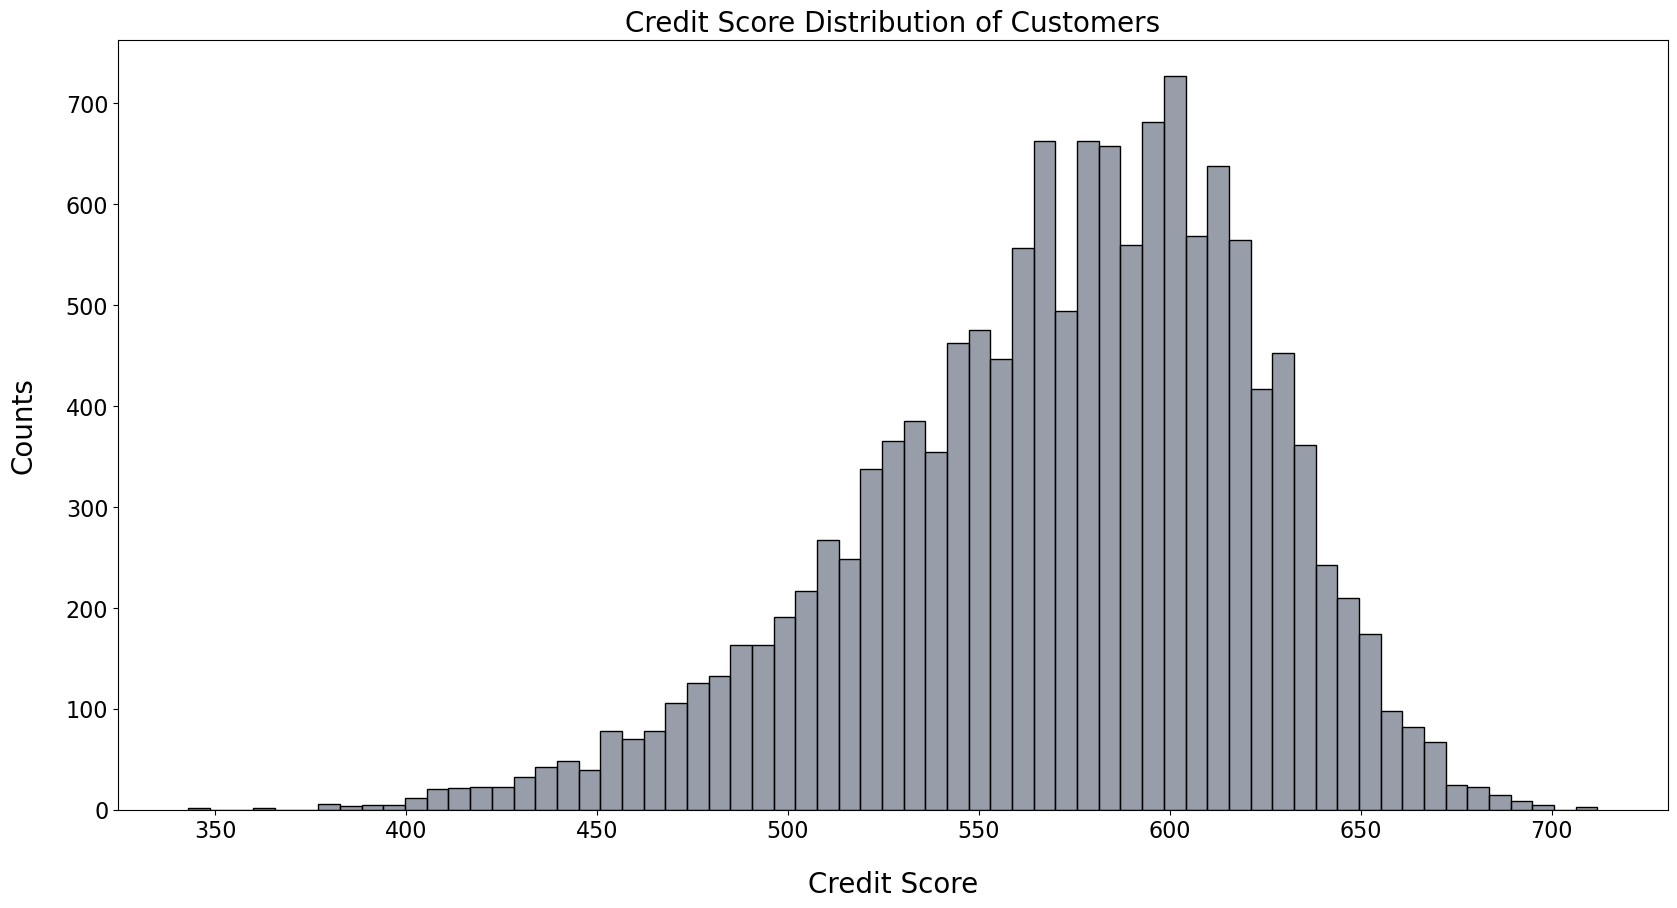

In [396]:
# Credit Score Distribution
plt.figure(figsize=(20,10))
ax = sns.histplot(data = X_train['CreditScore'], color='#747d8c')
plt.title("Credit Score Distribution of Customers", fontsize=20)
plt.xticks( fontsize=16)
plt.yticks( fontsize=16)
plt.xlabel('Credit Score', fontsize=20, labelpad=20)
plt.ylabel('Counts', fontsize=20, labelpad=20);

Distribusi customer berdasarkan credit score ternyata bentuknya left skew (Negative Skew).

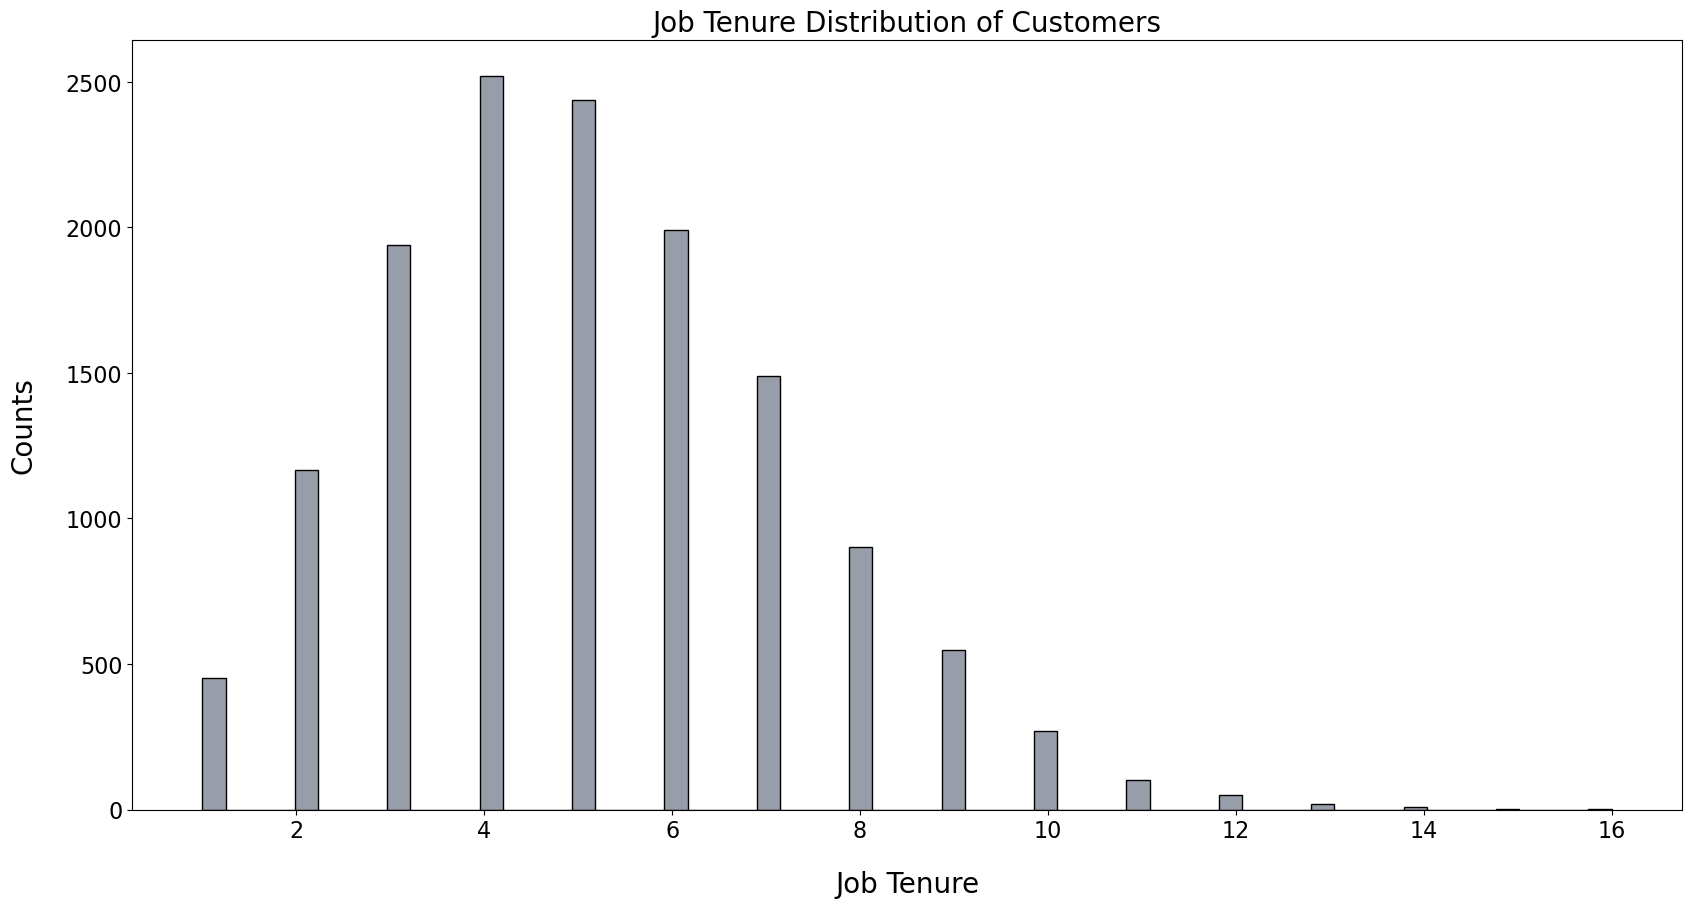

In [397]:
# Credit Score Distribution
plt.figure(figsize=(20,10))
ax = sns.histplot(data = X_train['JobTenure'], color='#747d8c')
plt.title("Job Tenure Distribution of Customers", fontsize=20)
plt.xticks( fontsize=16)
plt.yticks( fontsize=16)
plt.xlabel('Job Tenure', fontsize=20, labelpad=20)
plt.ylabel('Counts', fontsize=20, labelpad=20);

Distribusi customer berdasarkan Job Tenure ternyata bentuknya right skew (positive skew).

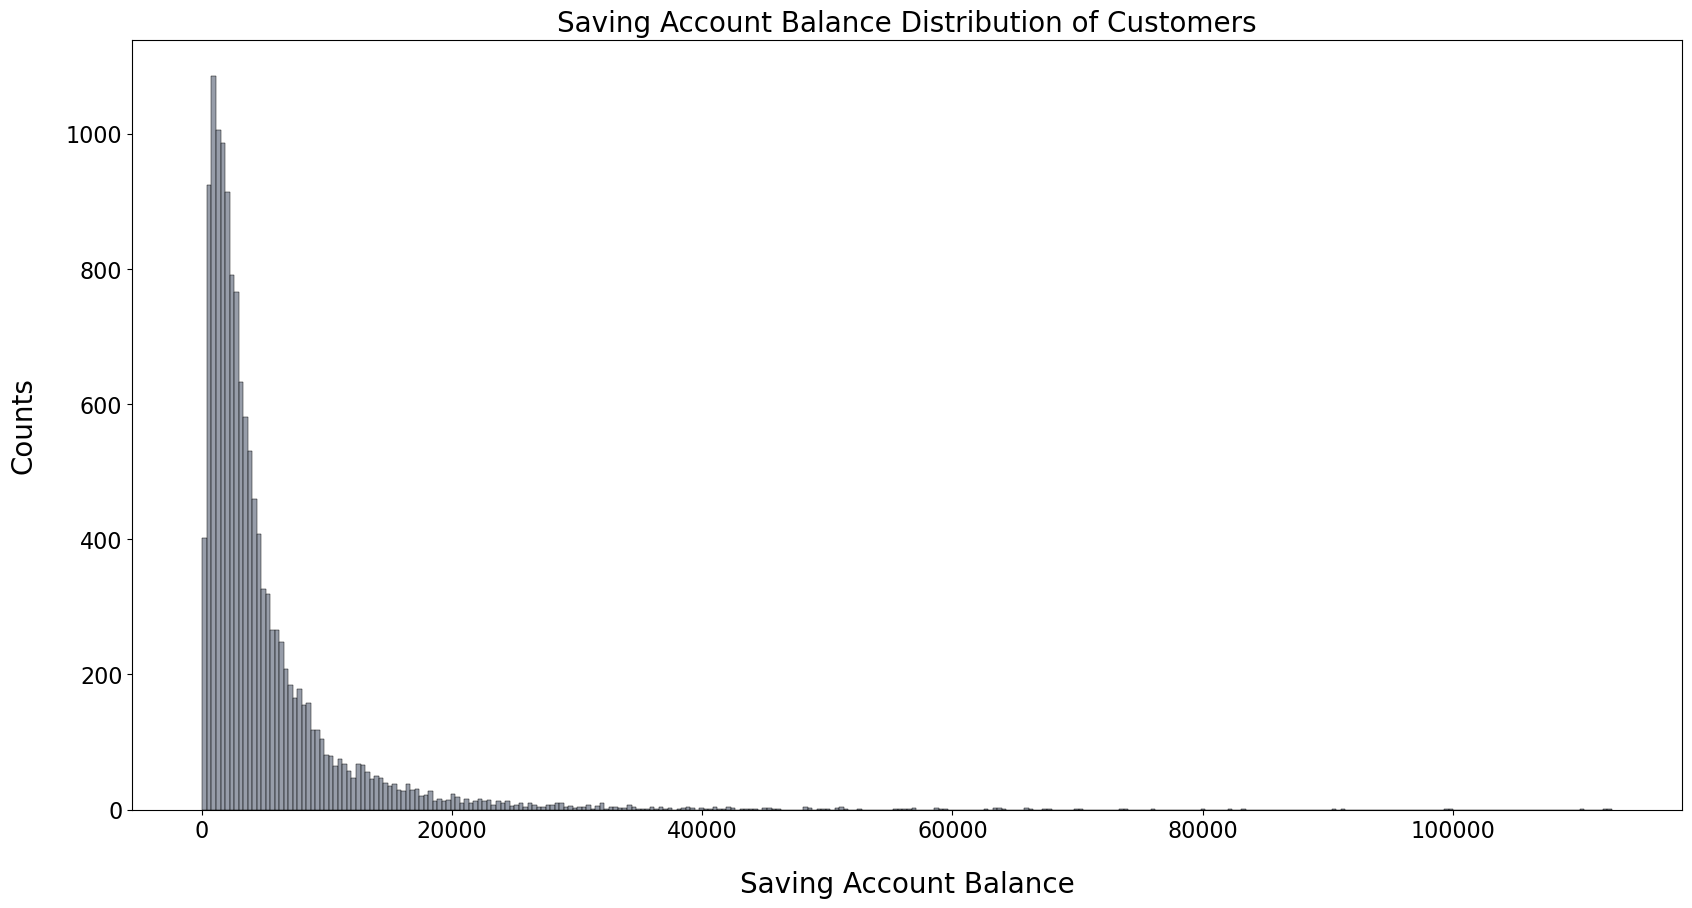

In [398]:
# Risk Score Distribution
plt.figure(figsize=(20,10))
ax = sns.histplot(data = X_train['SavingsAccountBalance'], color='#747d8c')
plt.title("Saving Account Balance Distribution of Customers", fontsize=20)
plt.xticks( fontsize=16)
plt.yticks( fontsize=16)
plt.xlabel('Saving Account Balance', fontsize=20, labelpad=20)
plt.ylabel('Counts', fontsize=20, labelpad=20);

Distribusi customer berdasarkan Saving Account Balance (rekening tabungan) ternyata bentuknya right skew (positive skew).

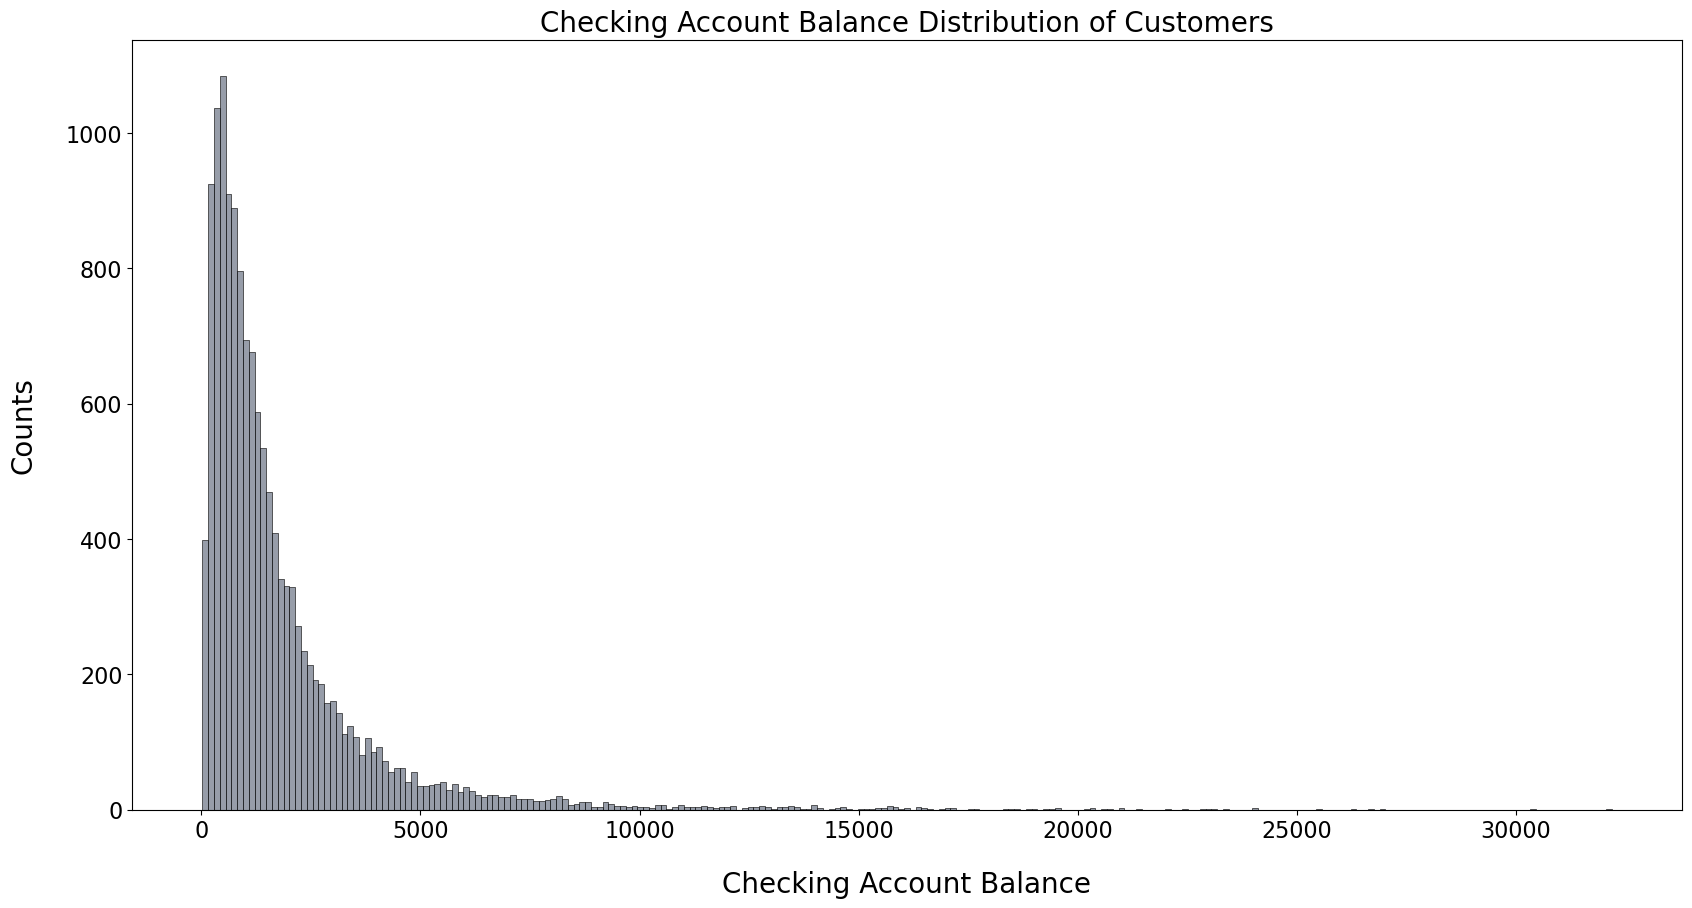

In [399]:
# Risk Score Distribution
plt.figure(figsize=(20,10))
ax = sns.histplot(data = X_train['CheckingAccountBalance'], color='#747d8c')
plt.title("Checking Account Balance Distribution of Customers", fontsize=20)
plt.xticks( fontsize=16)
plt.yticks( fontsize=16)
plt.xlabel('Checking Account Balance', fontsize=20, labelpad=20)
plt.ylabel('Counts', fontsize=20, labelpad=20);

Distribusi customer berdasarkan Checking Account Balance (rekening giro)ternyata bentuknya right skew (positive skew).

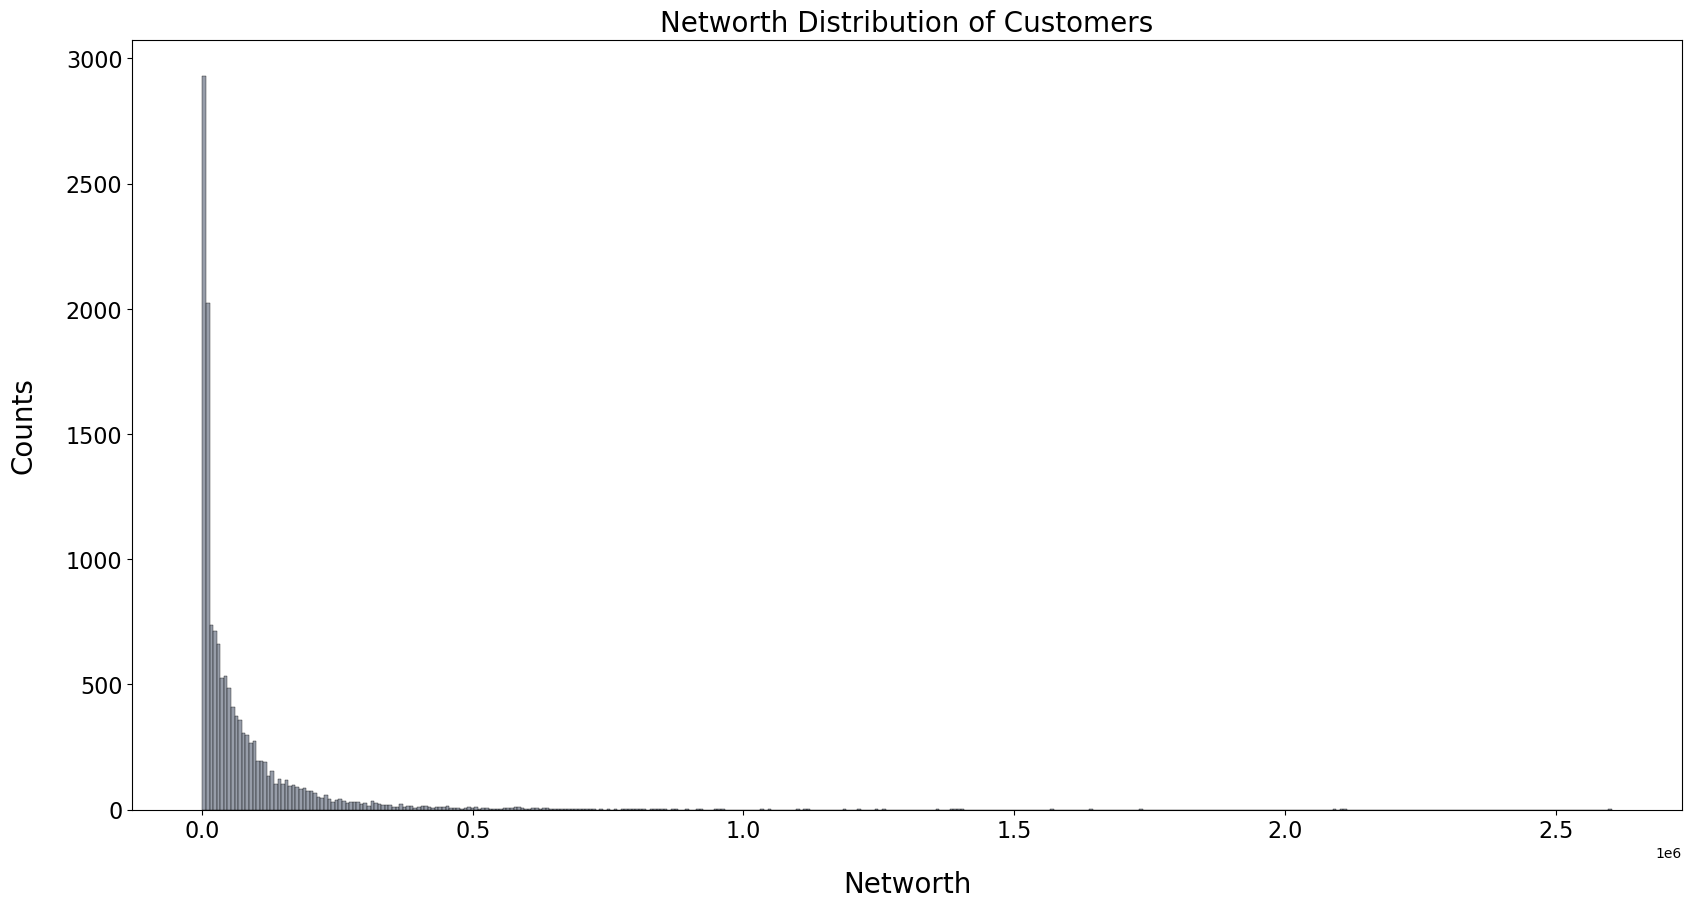

In [400]:
# Networth Distribution
plt.figure(figsize=(20,10))
ax = sns.histplot(data = X_train['NetWorth'], color='#747d8c')
plt.title("Networth Distribution of Customers", fontsize=20)
plt.xticks( fontsize=16)
plt.yticks( fontsize=16)
plt.xlabel('Networth', fontsize=20, labelpad=20)
plt.ylabel('Counts', fontsize=20, labelpad=20);

Distribusi customer berdasarkan Networth ternyata bentuknya right skew (positive skew).

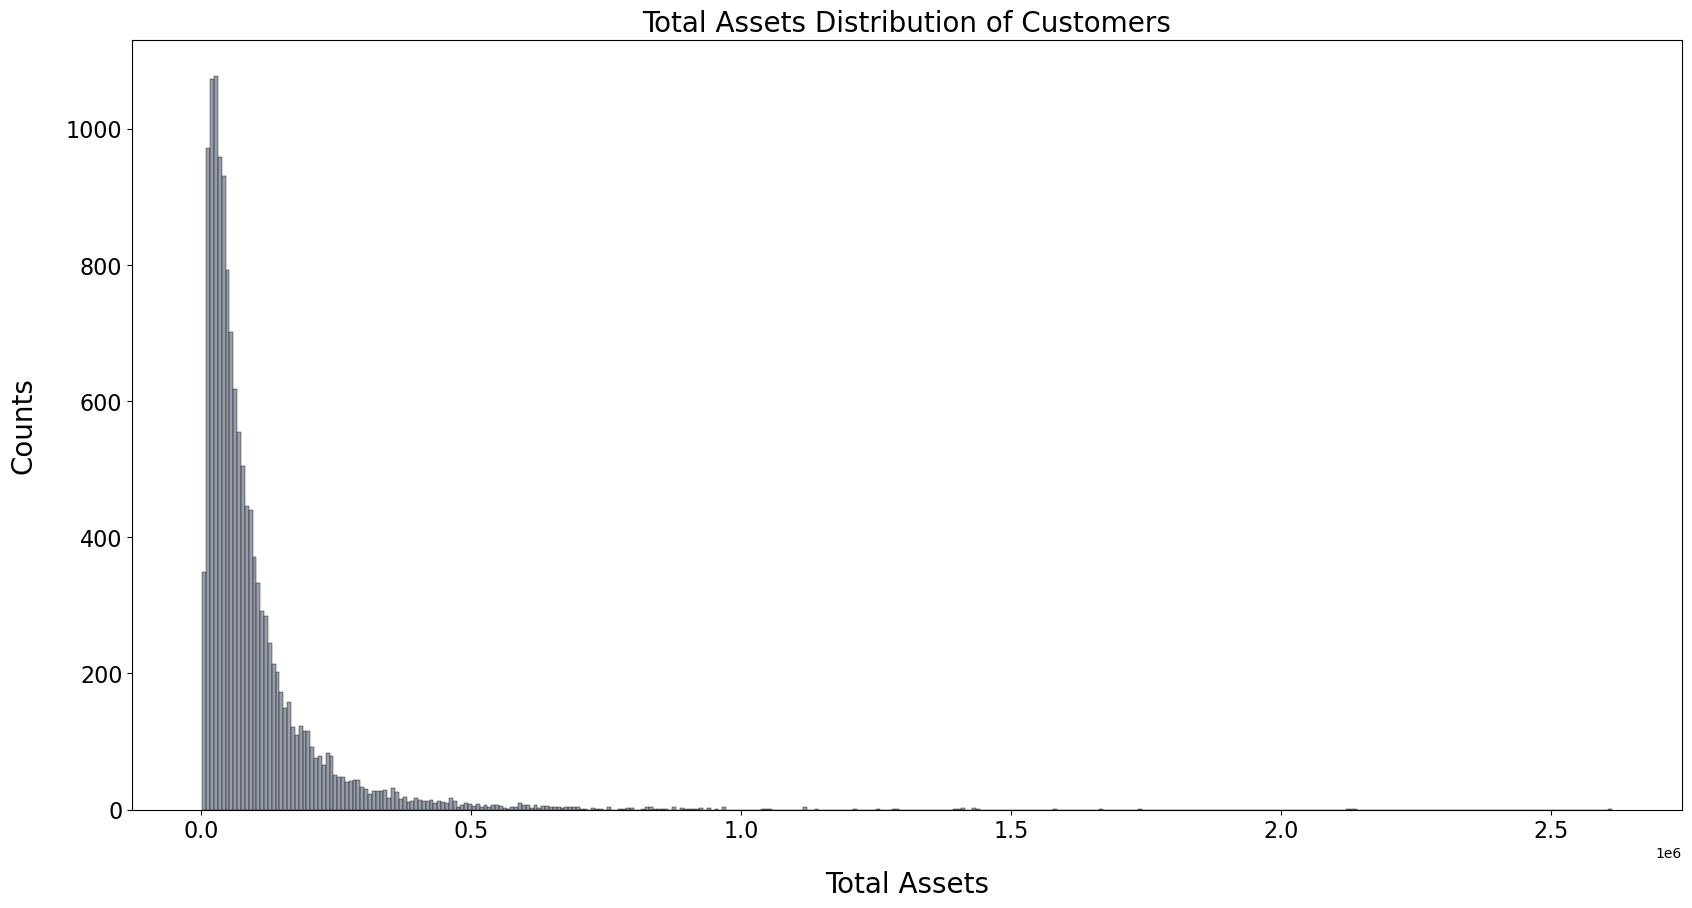

In [401]:
# Total Asets Distribution
plt.figure(figsize=(20,10))
ax = sns.histplot(data = X_train['TotalAssets'], color='#747d8c')
plt.title("Total Assets Distribution of Customers", fontsize=20)
plt.xticks( fontsize=16)
plt.yticks( fontsize=16)
plt.xlabel('Total Assets', fontsize=20, labelpad=20)
plt.ylabel('Counts', fontsize=20, labelpad=20);

Distribusi customer berdasarkan Total Aset ternyata bentuknya right skew (positive skew).

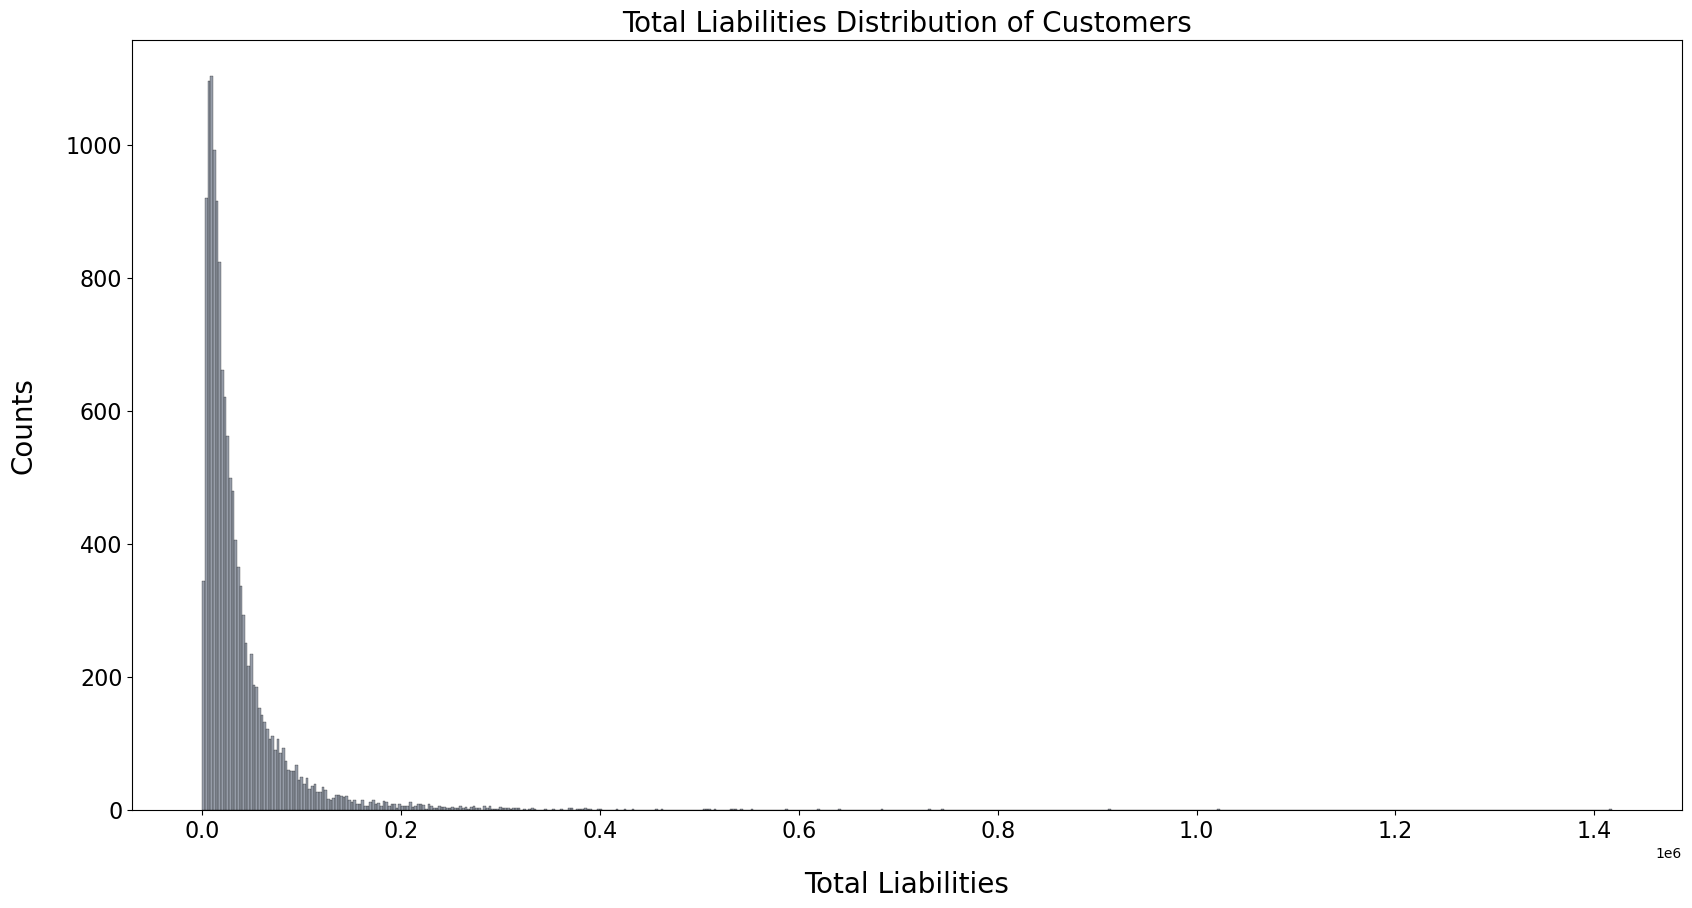

In [402]:
# Total Liabilities Distribution
plt.figure(figsize=(20,10))
ax = sns.histplot(data = X_train['TotalLiabilities'], color='#747d8c')
plt.title("Total Liabilities Distribution of Customers", fontsize=20)
plt.xticks( fontsize=16)
plt.yticks( fontsize=16)
plt.xlabel('Total Liabilities', fontsize=20, labelpad=20)
plt.ylabel('Counts', fontsize=20, labelpad=20);

Distribusi customer berdasarkan Total Liabilities ternyata bentuknya right skew (positive skew).

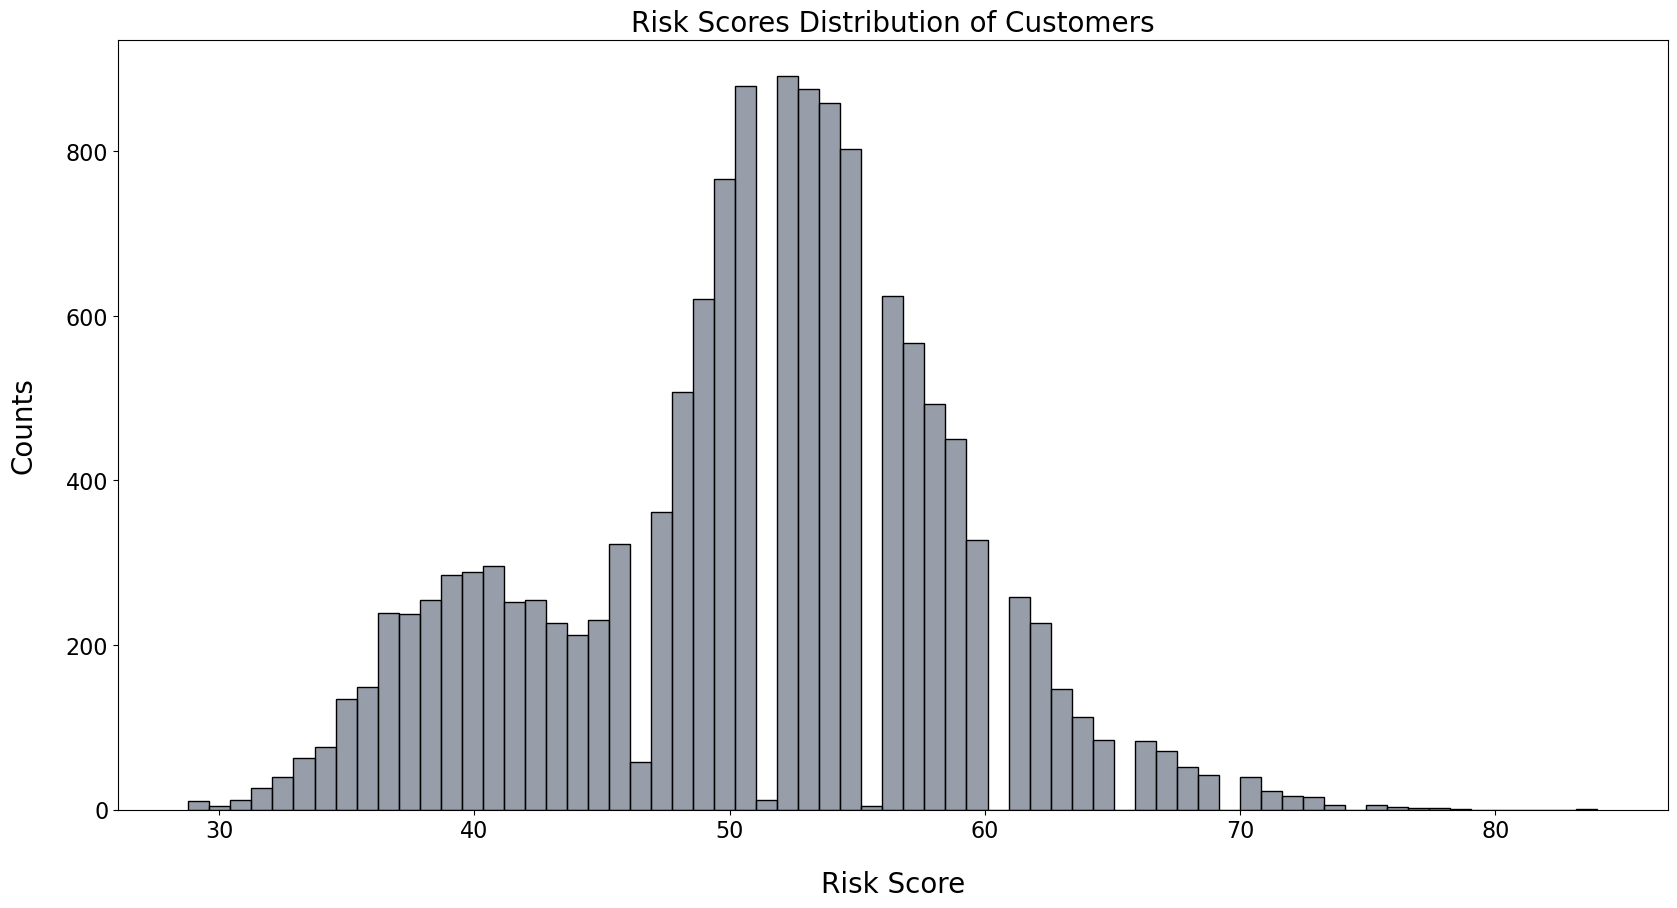

In [403]:
# Risk Score Distribution
plt.figure(figsize=(20,10))
ax = sns.histplot(data = X_train['RiskScore'], color='#747d8c')
plt.title("Risk Scores Distribution of Customers", fontsize=20)
plt.xticks( fontsize=16)
plt.yticks( fontsize=16)
plt.xlabel('Risk Score', fontsize=20, labelpad=20)
plt.ylabel('Counts', fontsize=20, labelpad=20);

Distribusi customer berdasarkan Risk Score ternyata bentuknya Multimodality (2 peaks).

## Multivariate Analysis

Relationship between annual income with credit score

/var/folders/lk/9kxh9jzd1y3g9klnhzw1xmsm0000gn/T/ipykernel_2680/4157640996.py:1: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.



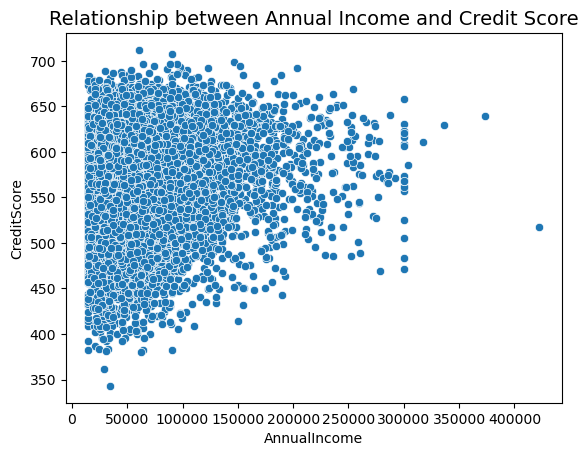

In [404]:
sns.scatterplot(data=X_train, x='AnnualIncome', y='CreditScore', palette='bone')
plt.title('Relationship between Annual Income and Credit Score', size=14)
plt.show()

/var/folders/lk/9kxh9jzd1y3g9klnhzw1xmsm0000gn/T/ipykernel_2680/1422114565.py:2: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.



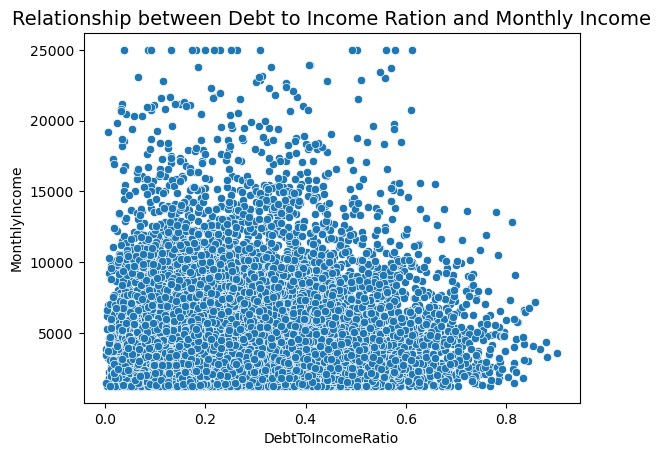

In [405]:
# Relationship between Debt to Income Ratio and Monthly Income
sns.scatterplot(data=X_train, x='DebtToIncomeRatio', y='MonthlyIncome', palette='bone')
plt.title('Relationship between Debt to Income Ration and Monthly Income', size=14)
plt.show()

Dari scatter plot ini dapat dilihat bahwa ketika seseorang memiliki rasio hutang terhadap income yang rendah, cenderung memiliki income bulanan yang tinggi. Sebaliknya, seseorang yang memiliki debt to income ratio yang tinggi cenderung memiliki income bulanan yang rendah.

/var/folders/lk/9kxh9jzd1y3g9klnhzw1xmsm0000gn/T/ipykernel_2680/3627625975.py:2: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.



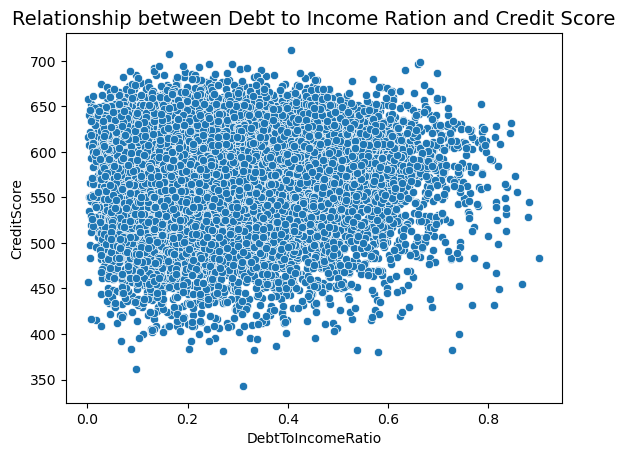

In [406]:
# Relationship between Debt to Income Ratio and Credit Score
sns.scatterplot(data=X_train, x='DebtToIncomeRatio', y='CreditScore', palette='bone')
plt.title('Relationship between Debt to Income Ration and Credit Score', size=14)
plt.show()

Jika dilihat hubungan antara debt to income ratio dengan credit score menunjukan bahwa semakin rendah nilai debt to income ratio maka credit scorenya cendeung besar.

/var/folders/lk/9kxh9jzd1y3g9klnhzw1xmsm0000gn/T/ipykernel_2680/2814248493.py:2: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.



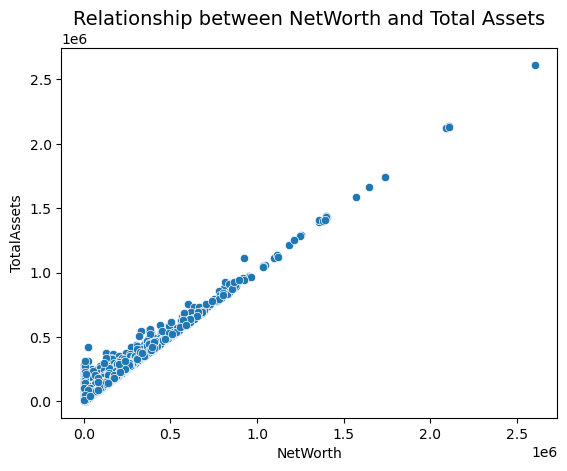

In [407]:
# Relationship between Net Worth and Total Assets
sns.scatterplot(data=X_train, x='NetWorth', y='TotalAssets', palette='bone')
plt.title('Relationship between NetWorth and Total Assets', size=14)
plt.show()

/var/folders/lk/9kxh9jzd1y3g9klnhzw1xmsm0000gn/T/ipykernel_2680/2307018960.py:2: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.



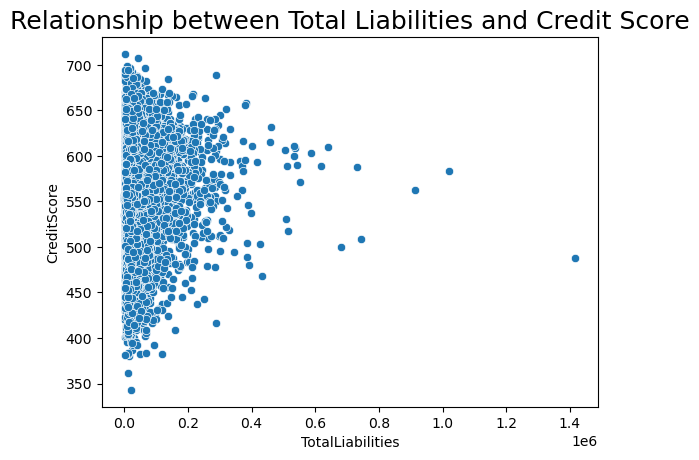

In [408]:
#Relationship between Total Liabilities and Credit Score
sns.scatterplot(data=X_train, x='TotalLiabilities', y='CreditScore', palette='bone')
plt.title('Relationship between Total Liabilities and Credit Score', size=18)
plt.show()

/var/folders/lk/9kxh9jzd1y3g9klnhzw1xmsm0000gn/T/ipykernel_2680/3792005572.py:2: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.



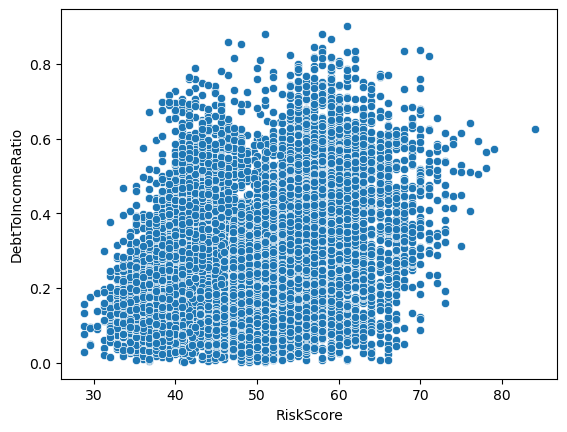

In [409]:
# Relation Ship between Risk Score and Debt To income Ratio
sns.scatterplot(data=X_train, x='RiskScore', y='DebtToIncomeRatio', palette='bone')
plt.show()

/var/folders/lk/9kxh9jzd1y3g9klnhzw1xmsm0000gn/T/ipykernel_2680/3952910948.py:2: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.



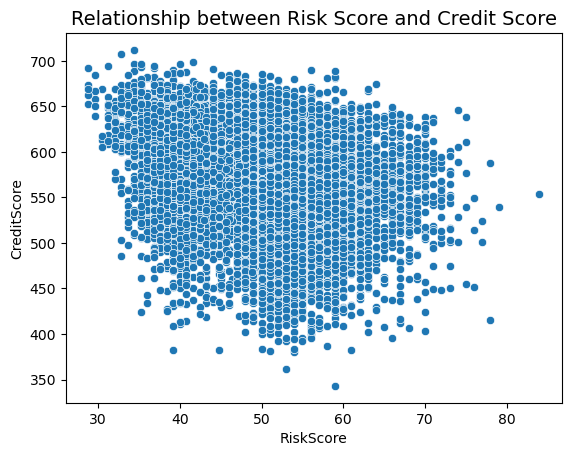

In [410]:
# Relation Ship between Risk Score and Credit Score
sns.scatterplot(data=X_train, x='RiskScore', y='CreditScore', palette='bone')
plt.title('Relationship between Risk Score and Credit Score', size=14)
plt.show()

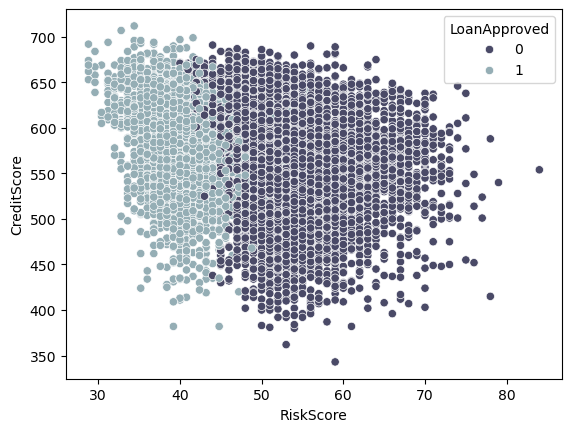

In [411]:
#Relationship between Risk Score and Credit Score toward Loan Approved Status
data = pd.DataFrame({
    'RiskScore': X_train['RiskScore'],
    'CreditScore':X_train['CreditScore'],
    'LoanApproved': y_train
})
sns.scatterplot(data=data, x='RiskScore', y='CreditScore', hue = 'LoanApproved', palette='bone')
plt.show()

Scatter plot ini nunjukin kalau Risk Score itu faktor yang signifikan buat keputusan approval loan. Orang-orang dengan Risk Score yang rendah tuh punya kemungkinan lebih besar buat loan-nya di-approve. Selain itu, keliatan juga ada risk score threshold di sekitar angka 50, di mana loan di bawah score ini punya chance lebih gede buat di-approve.

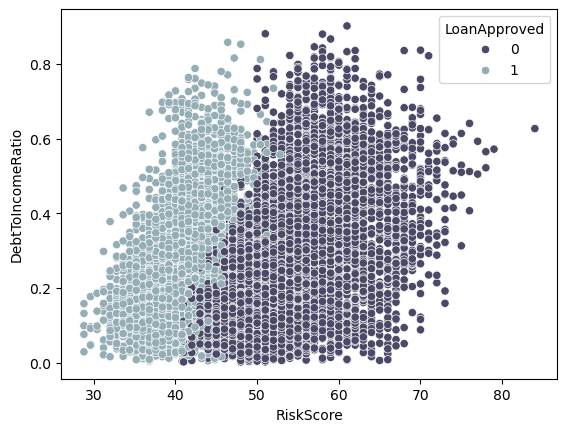

In [412]:
data = pd.DataFrame({
    'DebtToIncomeRatio': X_train['DebtToIncomeRatio'],
    'RiskScore':X_train['RiskScore'],
    'LoanApproved': y_train
})
sns.scatterplot(data=data, y='DebtToIncomeRatio', x='RiskScore', hue = 'LoanApproved', palette='bone')
plt.show()

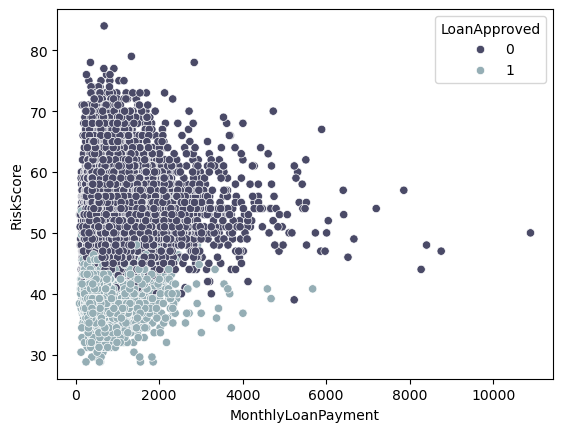

In [413]:
#Relationship between Risk Score and Monthly Loan Payment toward Loan Approved Status
data = pd.DataFrame({
    'MonthlyLoanPayment': X_train['MonthlyLoanPayment'],
    'RiskScore':X_train['RiskScore'],
    'LoanApproved': y_train
})
sns.scatterplot(data=data, y='RiskScore', x='MonthlyLoanPayment', hue = 'LoanApproved', palette='bone')
plt.show()

Dari scatter plot diatas dapat disimpulkan bahwa peminjaman yang diapprove mostly Monthly Loan Paymentnya dibawah 2000.

## Outlier

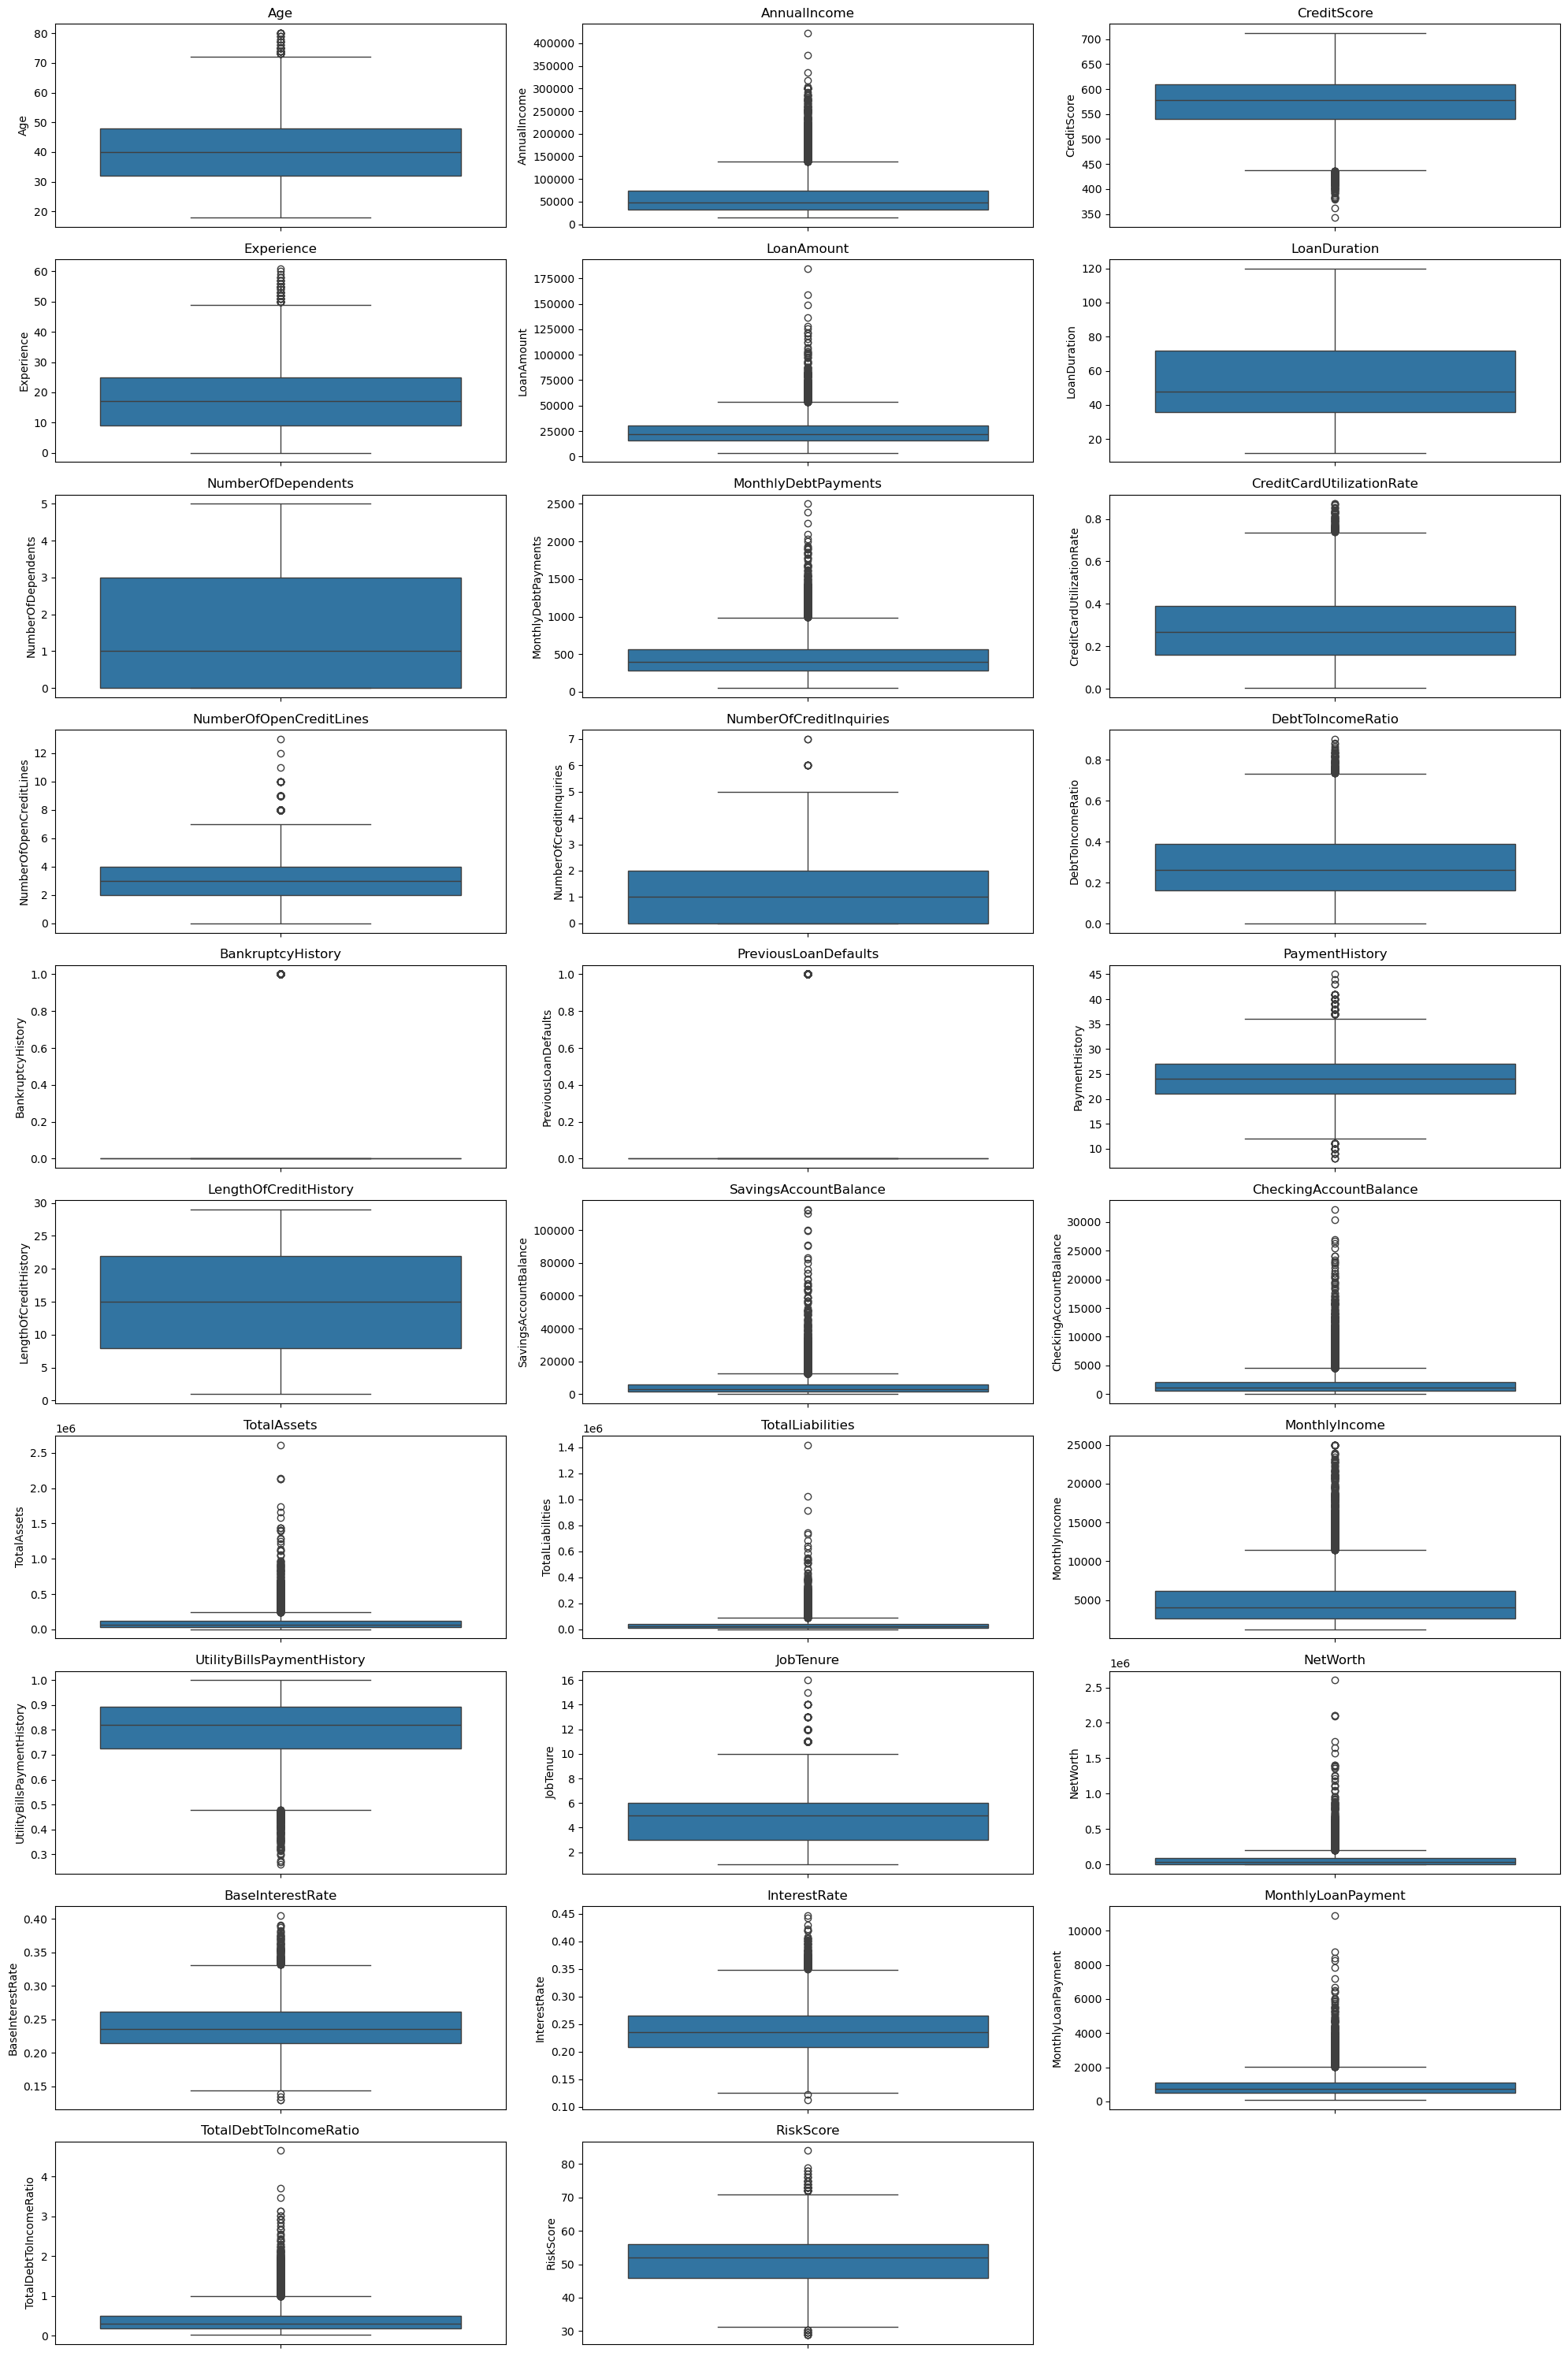

In [414]:
numerical = X_train.select_dtypes(include='number')
feature = numerical.columns.to_list()

features = numerical.columns.to_list()

# Mengatur ukuran figure
plt.figure(figsize=(20, 30))

for i in range(len(features)):
    plt.subplot(10, 3, i + 1)  # Mengatur grid 10 baris x 3 kolom
    sns.boxplot(data=numerical, y=features[i])
    plt.title(features[i])  # Menambahkan judul pada setiap plot
    plt.tight_layout()

plt.show()

In [415]:
def outliers(X_train):
    for col in numerical:
        Q1 = X_train[col].quantile(0.25)
        Q3 = X_train[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Mengganti nilai outlier dengan median
        median = X_train[col].median()
        X_train[col] = X_train[col].apply(lambda x: median if x < lower_bound or x > upper_bound else x)

    return X_train

X_train = outliers(X_train)

In [416]:
def outliers(X_test):
    for col in numerical:
        Q1 = X_test[col].quantile(0.25)
        Q3 = X_test[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Mengganti nilai outlier dengan median
        median = X_test[col].median()
        X_test[col] = X_test[col].apply(lambda x: median if x < lower_bound or x > upper_bound else x)

    return X_test

X_test = outliers(X_test)

In [417]:
X_train.shape, y_train.shape

((13893, 34), (13893,))

# Feature Selection

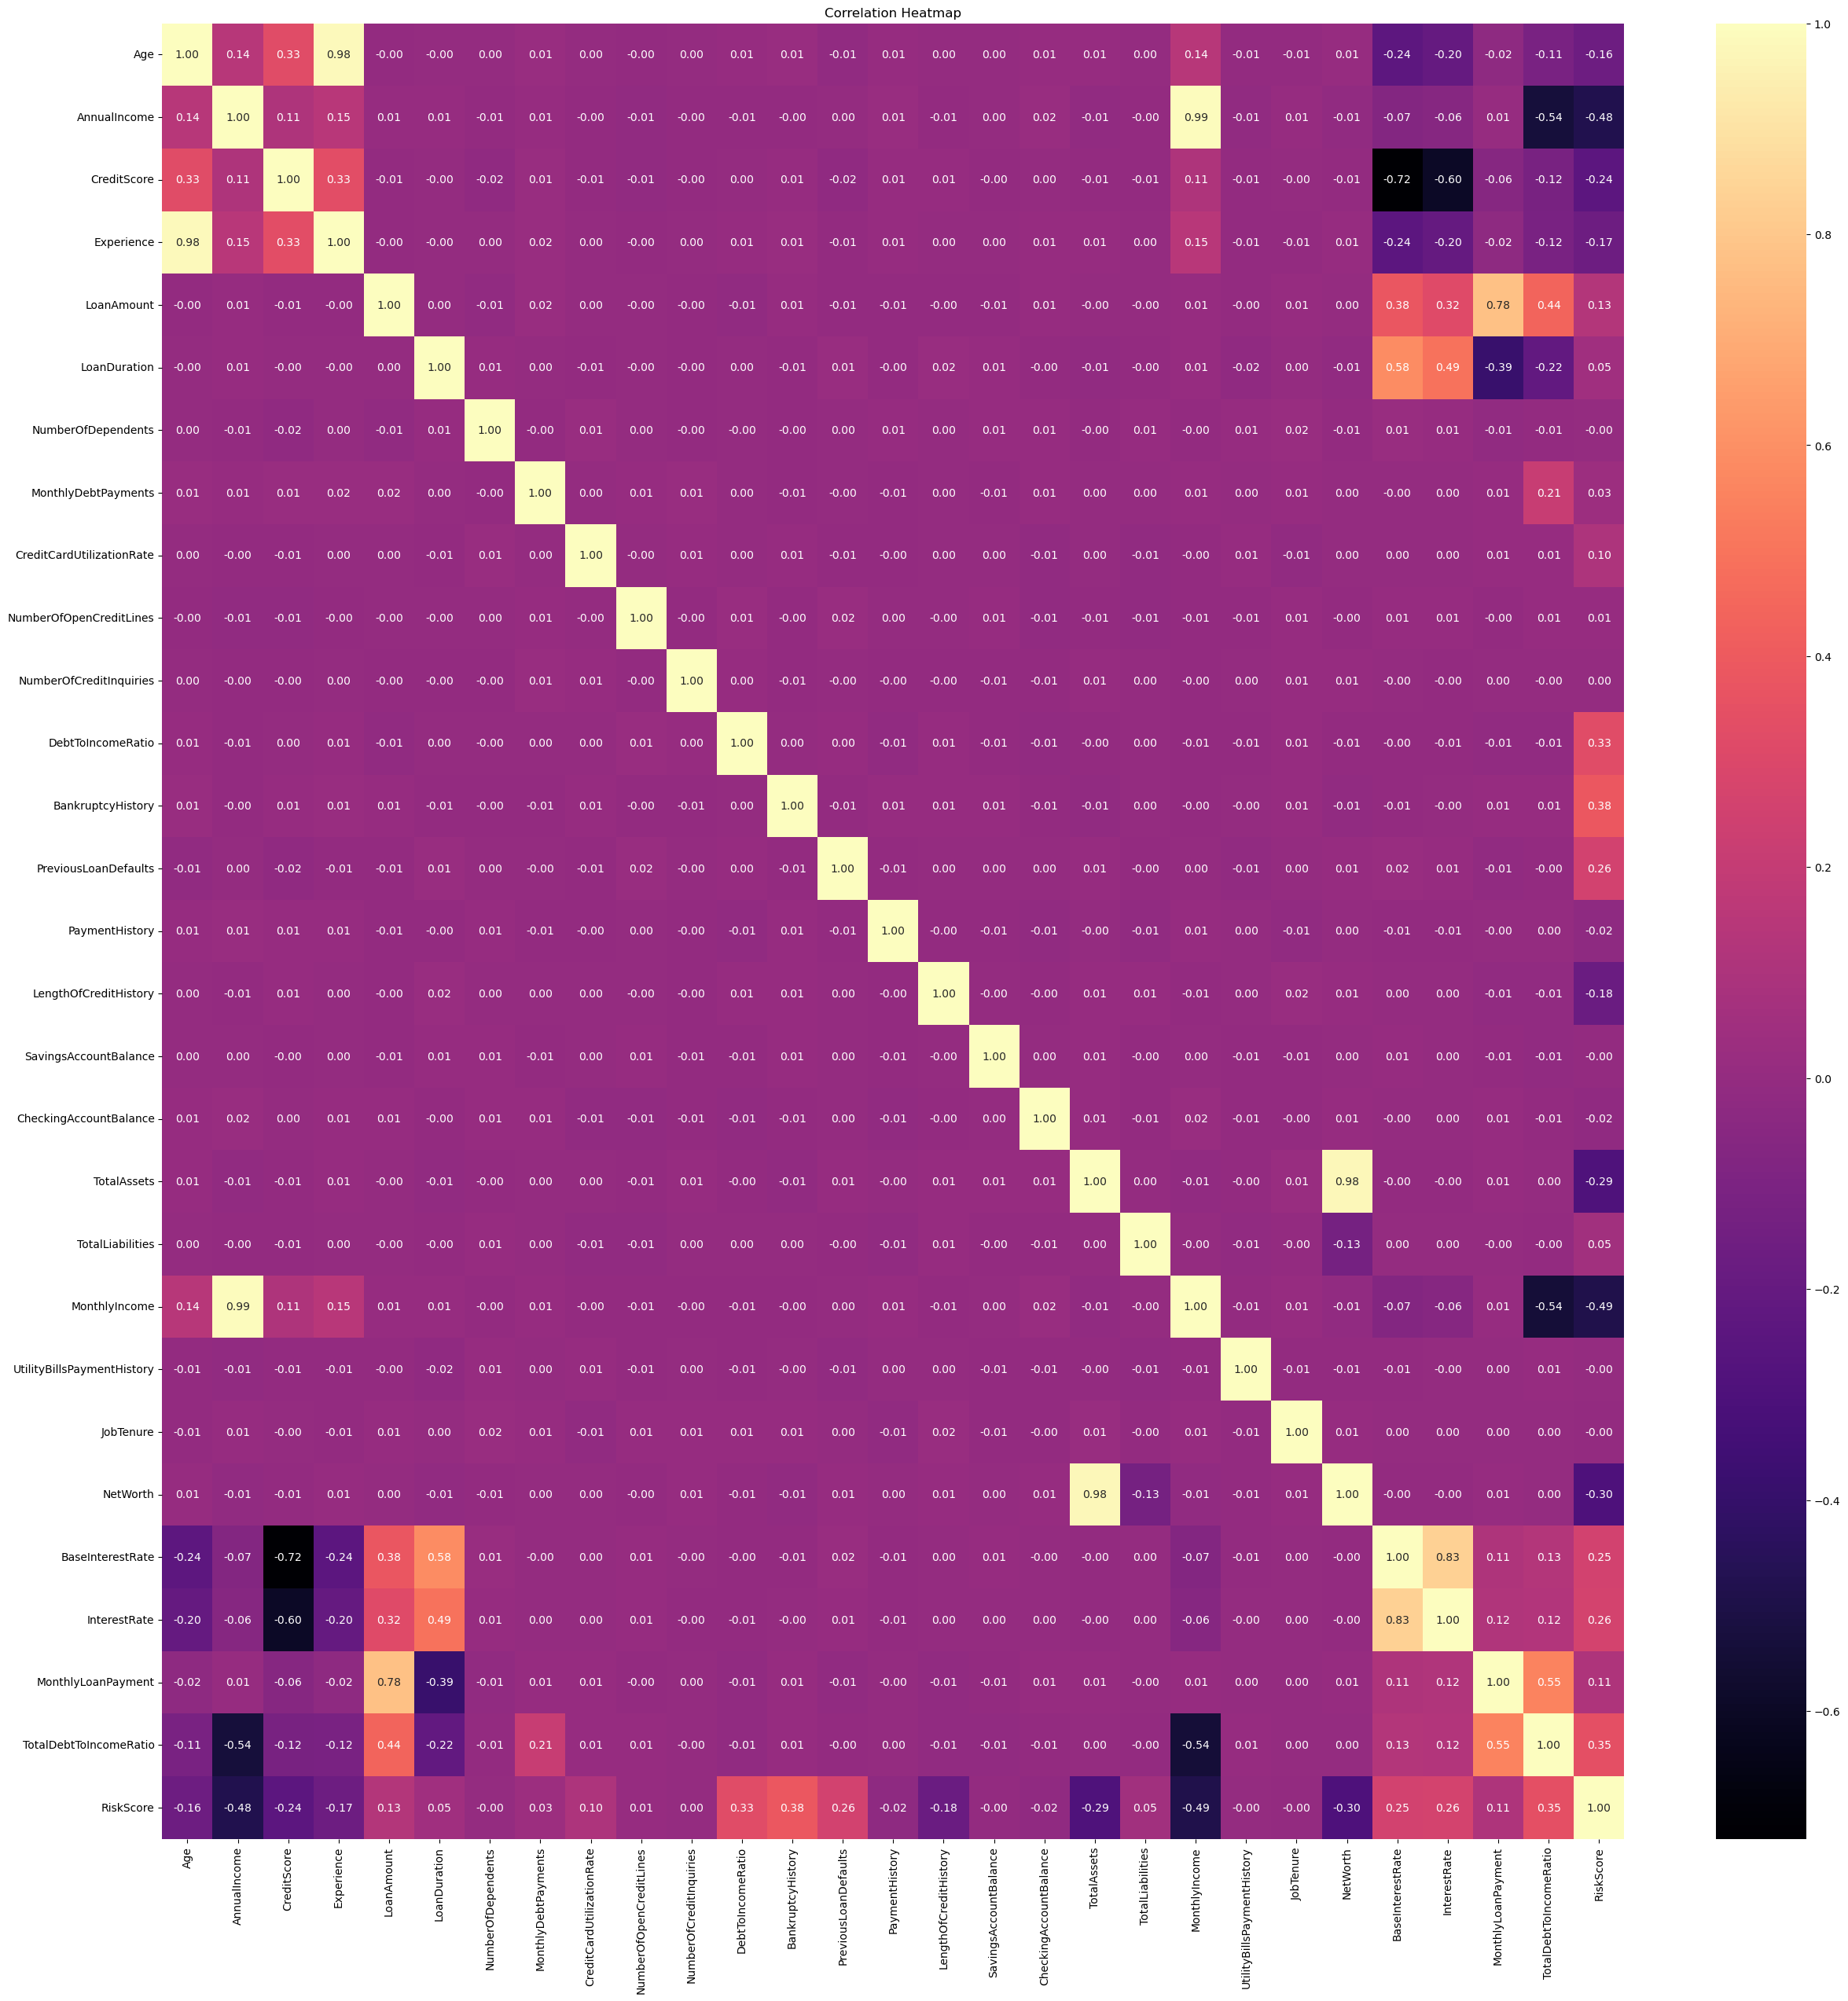

In [418]:
correlation_matrix = numerical.corr()
# Membuat heatmap
plt.figure(figsize=(30, 30))
sns.heatmap(correlation_matrix, annot=True, cmap='magma', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

Age, Experience, MonthlyIncome, AnnualIncome,MonthlyLoanPayment,LoanAmount,TotalAssets,NetWorth,BaseInterestRate,InterestRate,

In [419]:
drop_list = ['Age','Experience','MonthlyIncome','AnnualIncome','MonthlyLoanPayment','LoanAmount','TotalAssets','NetWorth','BaseInterestRate','InterestRate','RiskScore']
X_train = X_train.drop(drop_list, axis=1)
X_test = X_test.drop(drop_list, axis=1)

In [420]:
X_train.shape, X_test.shape

((13893, 23), (5955, 23))

In [421]:
X_train.isnull().sum()

CreditScore                   0
EmploymentStatus              0
EducationLevel                0
LoanDuration                  0
MaritalStatus                 0
NumberOfDependents            0
HomeOwnershipStatus           0
MonthlyDebtPayments           0
CreditCardUtilizationRate     0
NumberOfOpenCreditLines       0
NumberOfCreditInquiries       0
DebtToIncomeRatio             0
BankruptcyHistory             0
LoanPurpose                   0
PreviousLoanDefaults          0
PaymentHistory                0
LengthOfCreditHistory         0
SavingsAccountBalance         0
CheckingAccountBalance        0
TotalLiabilities              0
UtilityBillsPaymentHistory    0
JobTenure                     0
TotalDebtToIncomeRatio        0
dtype: int64

## Categorical Encoding

In [422]:
# One Hot Encoding
X_train = pd.get_dummies(X_train, columns=['EmploymentStatus', 'HomeOwnershipStatus', 'LoanPurpose'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['EmploymentStatus', 'HomeOwnershipStatus', 'LoanPurpose'], drop_first=True)

In [423]:
# Ordinal Encoding
edu= {
    'High School': 0,
    'Associate': 1,
    'Bachelor': 2,
    'Master': 3,
    'Doctorate': 4
}


# Apply the mapping to the 'Education' column
X_train['EducationLevel'] = X_train['EducationLevel'].map(edu)
X_test['EducationLevel'] = X_test['EducationLevel'].map(edu)



In [424]:
# Ordinal Encoding
marital_status_mapping = {
    'Single': 0,
    'Married': 1
}
X_train['MaritalStatus'] = X_train['MaritalStatus'].map(marital_status_mapping)
X_test['MaritalStatus'] = X_test['MaritalStatus'].map(marital_status_mapping)

In [425]:
X_train.shape, X_test.shape

((13893, 29), (5955, 29))

In [426]:
y_train.shape, y_test.shape

((13893,), (5955,))

In [427]:
X_train.head()

,CreditScore,EducationLevel,LoanDuration,MaritalStatus,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalLiabilities,UtilityBillsPaymentHistory,JobTenure,TotalDebtToIncomeRatio,EmploymentStatus_Self-Employed,EmploymentStatus_Unemployed,HomeOwnershipStatus_Other,HomeOwnershipStatus_Own,HomeOwnershipStatus_Rent,LoanPurpose_Debt Consolidation,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other
11682,638.0,3,84,0,2,572.0,0.408,4.0,1.0,0.603,0.0,0.0,26.0,14,2999.0,667.0,1575.0,0.710247,2.0,0.187,False,False,False,False,True,False,True,False,False
4903,545.0,0,60,0,0,140.0,0.305,6.0,0.0,0.225,0.0,0.0,24.0,9,3488.0,253.0,19839.0,0.759623,8.0,0.303,False,False,False,False,True,True,False,False,False
9392,444.0,1,84,0,2,280.0,0.096,2.0,0.0,0.183,0.0,0.0,27.0,23,1697.0,1005.0,5467.0,0.875803,5.0,0.361,False,False,False,True,False,False,False,False,True
8058,497.0,1,24,0,2,357.0,0.197,2.0,1.0,0.211,0.0,0.0,24.0,1,2999.0,1934.0,4717.0,0.840687,7.0,0.513,False,False,False,False,False,False,True,False,False
8405,570.0,3,96,0,4,341.0,0.316,1.0,1.0,0.154,0.0,0.0,25.0,7,5502.0,1176.0,19648.0,0.742416,5.0,0.183,False,False,False,False,True,False,True,False,False


In [428]:
# encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', dtype=int)

# # Fit the encoder on the combined categories from both datasets
# encoder.fit(pd.concat([X_train[categoric], X_test[categoric]]))

# # Transform the categorical columns in both datasets
# X_train_encoded = encoder.transform(X_train[categoric])
# X_test_encoded = encoder.transform(X_test[categoric])

# # Get the features name
# feature_names = encoder.get_feature_names_out(categoric)

# # Create data frames with encoded features
# X_train_encoded = pd.DataFrame(X_train_encoded,columns=feature_names,index = X_train.index)
# X_test_encoded = pd.DataFrame(X_test_encoded,columns=feature_names,index= X_test.index)

# # Concatenate encoded features with original DataFrames
# X_train = pd.concat([X_train.drop(columns=categoric), X_train_encoded], axis=1)
# X_test = pd.concat([X_test.drop(columns=categoric), X_test_encoded], axis=1)


# Modeling

In [429]:
# Logistic Regressor
lgr = Pipeline([
    ('scaler', StandardScaler()),  # Scaling fitur
    ('logistic', LogisticRegression(random_state=42))
])

# Fit model ke data training
lgr.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logistic', LogisticRegression(random_state=42))])

In [430]:
# # define random forest model
# lgr = LogisticRegression(
#     random_state = 42
# )
# # fit model to training data
# lgr.fit(X_train, y_train)

In [431]:
# define Decision Tree model
dt_clf = DecisionTreeClassifier(
    random_state = 42
)
# fit model to training data
dt_clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [432]:
# define random forest model
random_forest_clf = RandomForestClassifier(
    random_state = 42
)
# fit model to training data
random_forest_clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [433]:
# define XGBoost model
xgb_clf = XGBClassifier(
    random_state = 42
)
# fit model to training data
xgb_clf.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [434]:
# # LightGBM
# lgb_clf = LGBMClassifier(
#     random_state=42
# )

# lgb_clf.fit(X_train, y_train)

In [435]:
# # CatBoost Classifier model
# cbt_clf = CatBoostClassifier(
#     random_state = 42
# )

# cbt_clf.fit(X_train,y_train)

## Evaluation

In [436]:
# Logistic Regressor
lgr_pred = lgr.predict(X_test)
lgr_proba = lgr.predict_proba(X_test)

# Decision Tree Prediction
dt_pred = dt_clf.predict(X_test)
dt_pred_proba = dt_clf.predict_proba(X_test)

# Random Forest Prediction
rf_pred = random_forest_clf.predict(X_test)
rf_pred_proba = random_forest_clf.predict_proba(X_test)

# XGBoost prediction
xgb_pred = xgb_clf.predict(X_test)
xgb_pred_proba = xgb_clf.predict_proba(X_test)

# LightGBM Prediction
# lgb_pred = lgb_clf.predict(X_test)
# lgb_pred_proba = lgb_clf.predict_proba(X_test)

# CatBoost Prediction
# cbt_pred = cbt_clf.predict(X_test)
# cbt_predict_proba = cbt_clf.predict_proba(X_test)

### Prediction Result

In [437]:
# Logistic Regressor
pd.DataFrame(metrics.classification_report(y_test, lgr_pred, target_names=['0','1'], output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.921064,0.802404,0.894542,0.861734,0.892510
recall,0.941840,0.745290,0.894542,0.843565,0.894542
f1-score,0.931336,0.772793,0.894542,0.852065,0.893185
support,4522.000000,1433.000000,0.894542,5955.000000,5955.000000


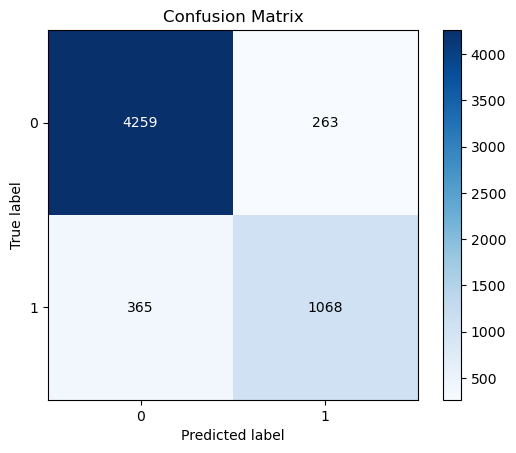

In [438]:
skplt.metrics.plot_confusion_matrix(y_test, lgr_pred);

In [439]:
# Decision Tree
pd.DataFrame(metrics.classification_report(y_test, dt_pred, target_names=['0','1'], output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.896374,0.652320,0.835432,0.774347,0.837645
recall,0.885670,0.676902,0.835432,0.781286,0.835432
f1-score,0.890990,0.664384,0.835432,0.777687,0.836460
support,4522.000000,1433.000000,0.835432,5955.000000,5955.000000


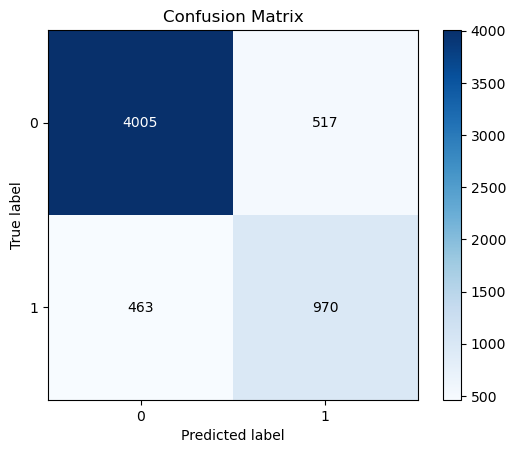

In [440]:
skplt.metrics.plot_confusion_matrix(y_test, dt_pred);

In [441]:
# Random Forest
pd.DataFrame(metrics.classification_report(y_test, rf_pred, target_names=['0','1'], output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.906756,0.822259,0.889673,0.864508,0.886423
recall,0.952676,0.690858,0.889673,0.821767,0.889673
f1-score,0.929149,0.750853,0.889673,0.840001,0.886244
support,4522.000000,1433.000000,0.889673,5955.000000,5955.000000


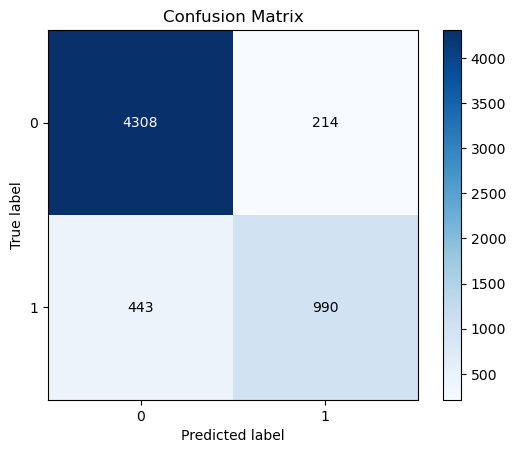

In [442]:
skplt.metrics.plot_confusion_matrix(y_test, rf_pred);

In [443]:
# XGBoost Classifer 
pd.DataFrame(metrics.classification_report(y_test, xgb_pred, target_names=['0','1'], output_dict=True))

,0,1,accuracy,macro avg,weighted avg
precision,0.917909,0.794118,0.890344,0.856013,0.888120
recall,0.939628,0.734822,0.890344,0.837225,0.890344
f1-score,0.928642,0.763320,0.890344,0.845981,0.888859
support,4522.000000,1433.000000,0.890344,5955.000000,5955.000000


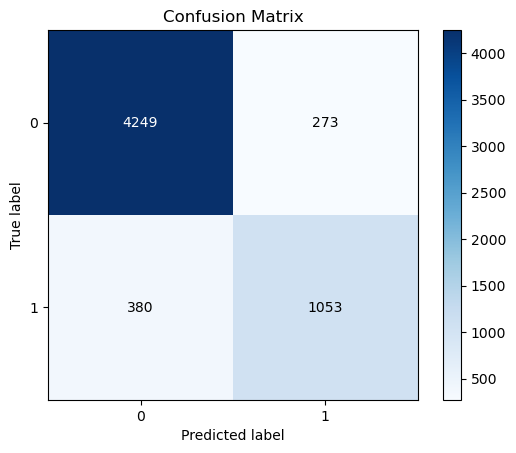

In [444]:
skplt.metrics.plot_confusion_matrix(y_test, xgb_pred);

### Hyperparameter Tuning

In [445]:
# Pipeline for Logistic Regression
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),   # Step to handle class imbalance
    ('logreg', LogisticRegression(solver='liblinear', random_state=42))  # Logistic Regression step
])

# Define the hyperparameters to search over
param_grids = {
    'logreg__C': [0.01, 0.1, 1, 10, 100],          # Regularization strength
    'logreg__penalty': ['l1', 'l2']               # Type of regularization
}

# Define the cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grids,
    cv=cv,
    scoring='precision',  # Change this to the metric you prefer
    n_jobs=-1,           # Use all available cores for parallel processing
    verbose=0            # Set verbosity to 0 to suppress output
)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Get the best cross-validation score
best_score = grid_search.best_score_

# Display only the best cross-validation score
print(f"Best cross-validation score: {best_score:.4f}")

# Use the best model for predictions
best_model = grid_search.best_estimator_
logreg_proba = best_model.predict_proba(X_test)

# Apply threshold 0.8 for class 1 predictions
threshold = 0.8
logreg_pred_th = (logreg_proba[:, 1] >= threshold).astype(int)

# Evaluate the performance on the test set
accuracy = accuracy_score(y_test, logreg_pred_th)
print(f"Test set accuracy with threshold {threshold}: {accuracy:.4f}")


Best cross-validation score: 0.6700
Test set accuracy with threshold 0.8: 0.8777


In [446]:
from sklearn.metrics import classification_report, accuracy_score

# Display the best parameters and the best score
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score: ", grid_search.best_score_)

# Use best model
best_model = grid_search.best_estimator_

# Predictions with threshold 0.8
threshold = 0.8
logreg_test_pred_th = (best_model.predict_proba(X_test)[:, 1] >= threshold).astype(int)

# Calculate accuracy for test data (threshold 0.8)
test_accuracy_threshold = accuracy_score(y_test, logreg_test_pred_th)

# Display the accuracy
print(f"Logistic Regression Model")
print(f"Test Accuracy (Threshold {threshold}): {test_accuracy_threshold:.4f}")

print(f"\nClassification Report (Threshold {threshold}):")
print(classification_report(y_test, logreg_test_pred_th))


Best parameters found:  {'logreg__C': 1, 'logreg__penalty': 'l1'}
Best cross-validation score:  0.6699724772689509
Logistic Regression Model
Test Accuracy (Threshold 0.8): 0.8777

Classification Report (Threshold 0.8):
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      4522
           1       0.85      0.60      0.70      1433

    accuracy                           0.88      5955
   macro avg       0.87      0.78      0.81      5955
weighted avg       0.88      0.88      0.87      5955



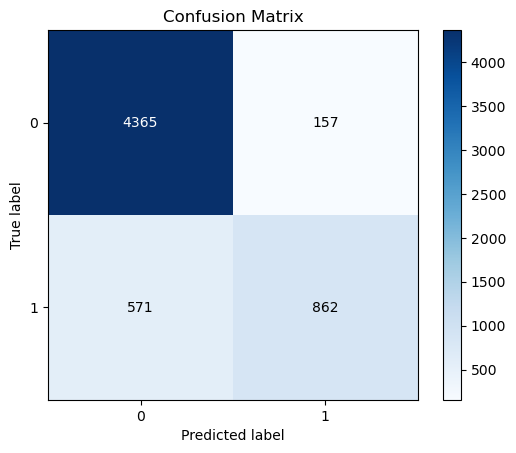

In [447]:
skplt.metrics.plot_confusion_matrix(y_test, logreg_test_pred_th);

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:87: FutureWarning:

Function plot_roc_curve is deprecated; This will be removed in v0.5.0. Please use scikitplot.metrics.plot_roc instead.



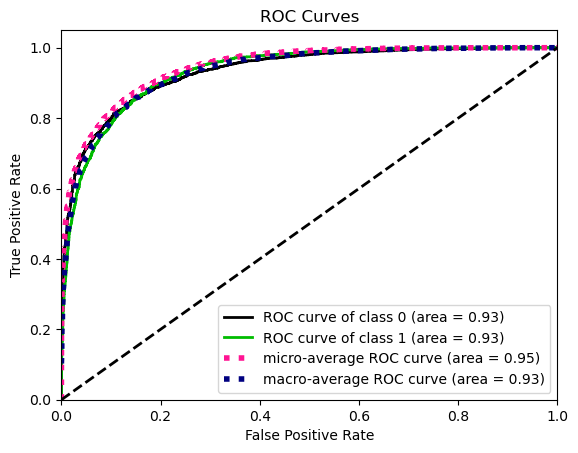

In [448]:
# Logistic Regressor result
skplt.metrics.plot_roc_curve(y_test, logreg_proba);

Random Forest

In [449]:
# Pipeline for Random Forest
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),  # Step to handle class imbalance
    ('rf', RandomForestClassifier(random_state=42))  # Random Forest step
])

# Define the hyperparameters to search over
param_grids = {
    'rf__n_estimators': [50, 100, 200],          # Number of trees
    'rf__max_depth': [10, 20, 30],         # Maximum depth of trees
    'rf__min_samples_split': [2, 5, 10],         # Minimum samples to split an internal node
    'rf__min_samples_leaf': [1, 2, 5]           # Minimum samples in a leaf node
}

# Define the cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grids,
    cv=cv,
    scoring='precision',  # Change this to the metric you prefer
    n_jobs=-1,            # Use all available cores for parallel processing
    verbose=0             # Set verbosity to 0 to suppress output
)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Get the best cross-validation score
best_score = grid_search.best_score_

# Display only the best cross-validation score
print(f"Best cross-validation score: {best_score:.4f}")

# Use the best model for predictions
best_model = grid_search.best_estimator_
rf_proba = best_model.predict_proba(X_test)

# Apply threshold 0.8 for class 1 predictions
threshold = 0.8
rf_pred_th = (rf_proba[:, 1] >= threshold).astype(int)

# Evaluate the performance on the test set
accuracy = accuracy_score(y_test, rf_pred_th)
print(f"Test set accuracy with threshold {threshold}: {accuracy:.4f}")


Best cross-validation score: 0.7388
Test set accuracy with threshold 0.8: 0.8257


In [450]:
from sklearn.metrics import classification_report, accuracy_score

# Display the best parameters and the best score
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score: ", grid_search.best_score_)

# Use best model
best_model = grid_search.best_estimator_

# Predictions with threshold 0.8
threshold = 0.8
logreg_test_pred_th = (best_model.predict_proba(X_test)[:, 1] >= threshold).astype(int)

# Calculate accuracy for test data (threshold 0.8)
test_accuracy_threshold = accuracy_score(y_test, rf_pred_th)

# Display the accuracy
print(f"Logistic Regression Model")
print(f"Test Accuracy (Threshold {threshold}): {test_accuracy_threshold:.4f}")

print(f"\nClassification Report (Threshold {threshold}):")
print(classification_report(y_test, rf_pred_th))


Best parameters found:  {'rf__max_depth': 30, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 5, 'rf__n_estimators': 200}
Best cross-validation score:  0.7388243320918615
Logistic Regression Model
Test Accuracy (Threshold 0.8): 0.8257

Classification Report (Threshold 0.8):
              precision    recall  f1-score   support

           0       0.82      0.99      0.90      4522
           1       0.90      0.31      0.46      1433

    accuracy                           0.83      5955
   macro avg       0.86      0.65      0.68      5955
weighted avg       0.84      0.83      0.79      5955



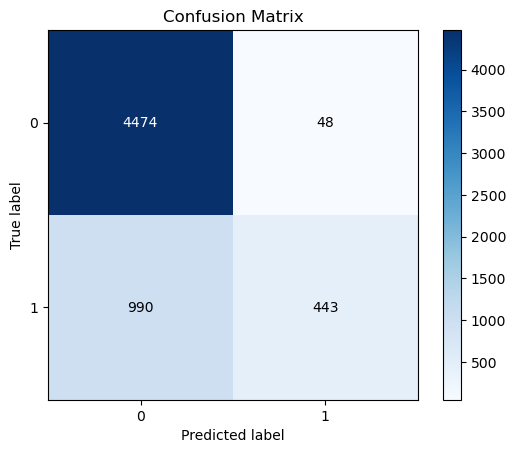

In [451]:
skplt.metrics.plot_confusion_matrix(y_test, rf_pred_th);

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:87: FutureWarning:

Function plot_roc_curve is deprecated; This will be removed in v0.5.0. Please use scikitplot.metrics.plot_roc instead.



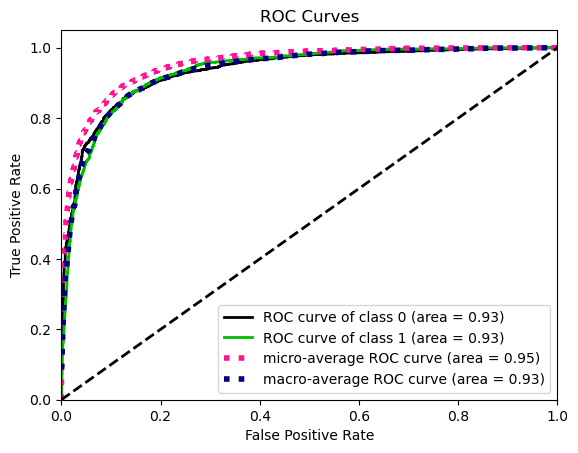

In [452]:
# Random Forest result
skplt.metrics.plot_roc_curve(y_test, rf_proba);

# Model Agnostic

In [453]:
## initiate explainer for XGBoost model
rf_exp = dx.Explainer(random_forest_clf, X_train, y_train, label = "Random Forest Interpretation")

Preparation of a new explainer is initiated

  -> data              : 13893 rows 29 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 13893 values
  -> model_class       : sklearn.ensemble._forest.RandomForestClassifier (default)
  -> label             : Random Forest Interpretation
  -> predict function  : <function yhat_proba_default at 0x307dbf740> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.0, mean = 0.24, max = 1.0
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.4, mean = -0.00189, max = 0.47
  -> model_info        : package sklearn

A new explainer has been created!


## Feature Importance

In [454]:
rf_exp.model_parts().plot()

## Shapley Value and Shapley Additive Explanation

In [455]:
# create sample used for developing shapley
data_for_shapley = X_train.sample(n=1000, random_state=1000)


In [456]:
# create SHAP Tree Explainer for random forest model with first 1000 rows of train data
rf_shap_values = shap.TreeExplainer(random_forest_clf).shap_values(data_for_shapley)

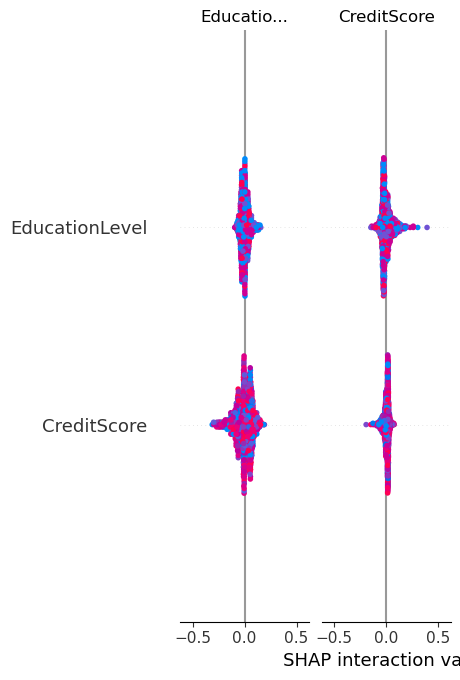

In [457]:
# create shap summary plot with next 1000 rows of train data
shap.summary_plot(rf_shap_values, X_train[1000:2000],plot_type='bar')